# 03: Pravila asocijacije

Rudarenje nad objedinjenim korpusom: teme→teme, reči→teme, teme→reči (potpisi), reč→reč, sekvencijalna pravila na redosledu rečenica, privlačenja/odbijanja reč↔tema i pravila na **anotiranim rečenicama**. Transakcija = dokument sa top-15 TF-IDF rečima + oznakama kao stavkama `CLASS_X` (imena klasa su stop-listana da tautologija {religion}→RELIGION ne može biti iskopana).


In [1]:
import os, sys, time, warnings
if os.path.exists("vocabs.txt"):
    ROOT = os.getcwd()
elif os.path.exists("../vocabs.txt"):
    ROOT = os.path.abspath("..")
else:
    raise FileNotFoundError("Nije pronadjen path")
os.chdir(ROOT)
os.makedirs("csv", exist_ok=True); sys.path.insert(0, ROOT)
print("ROOT =", ROOT)
%matplotlib inline
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.sparse import issparse
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.cluster import (KMeans, BisectingKMeans,
                             AgglomerativeClustering, Birch, DBSCAN,
                             SpectralClustering)
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (adjusted_rand_score, silhouette_score,
                             davies_bouldin_score,
                             calinski_harabasz_score)
from sklearn.manifold import TSNE


import nbformat
_p1 = next(p for p in ("notebooks/01_preprocessing.ipynb",
                       "01_preprocessing.ipynb") if os.path.exists(p))
_nb1 = nbformat.read(_p1, as_version=4)
for _c in _nb1.cells:
    if _c.cell_type == "code" and _c.metadata.get("tools"):
        exec(compile(_c.source, "<01_alati>", "exec"), globals())
print("alati iz 01_preprocessing učitani")


_p2 = next(p for p in ("notebooks/02_clustering.ipynb",
                       "02_clustering.ipynb") if os.path.exists(p))
_nb2 = nbformat.read(_p2, as_version=4)
for _c in _nb2.cells:
    if _c.cell_type == "code" and _c.metadata.get("tools"):
        exec(compile(_c.source, "<02_alati>", "exec"), globals())
print("alati iz 02_clustering učitani")


ROOT = C:\Users\Trile\PycharmProjects\PythonProject3\important!
alati iz 01_preprocessing učitani
alati iz 02_clustering učitani


## 1. Transakcije


In [2]:
def class_tag(c):
    return f"CLASS_{CLASS_NAMES[c].upper()}"



CLASS_WORD_STOPLIST = {
    "program", "programm", "style", "refer", "referenc", "java",
    "web", "internet", "cultur", "design", "educ", "educat",
    "languag", "language", "book", "books", "write", "writing",
    "comput", "computer", "english", "polit", "politics", "histori",
    "histor", "philosophi", "scienc", "religion", "grammar",
}
RULE_COLS = ["antecedents", "consequents", "support", "confidence",
             "lift", "leverage", "conviction"]

In [3]:
def label_transactions(Y):
    return [[class_tag(i) for i, value in enumerate(row) if value]
            for row in Y]



def topk_word_class_transactions(term_matrix,
                                 document_label_matrix, terms,
                                 top_k=15):
    out = []
    for d in range(term_matrix.shape[0]):
        row = term_matrix.getrow(d)
        if top_k is None:
            top = row.indices
        else:
            top = row.indices[np.argsort(row.data)[::-1][:top_k]]
        words = {terms[j] for j in top
                 if terms[j] not in CLASS_WORD_STOPLIST}
        for c, value in enumerate(document_label_matrix[d]):
            if value:
                words.add(class_tag(c))
        out.append(list(words))
    return out



def strip_classes(transactions):
    return [[x for x in transaction
             if not str(x).startswith("CLASS_")]
            for transaction in transactions]


In [4]:
def has_class(items):
    return any(str(x).startswith("CLASS_") for x in items)



def _pure_class(item_set):
    return (len(item_set) > 0
            and all(str(x).startswith("CLASS_") for x in item_set))



def _pure_words(item_set):
    return (len(item_set) > 0
            and not any(str(x).startswith("CLASS_")
                        for x in item_set))



def m_drop_self(rules):
    return rules[~rules.apply(
        lambda row: row["antecedents"] == row["consequents"],
        axis=1)]



def m_words_class(rules):
    return rules[rules["consequents"].apply(has_class)
                 & ~rules["antecedents"].apply(has_class)
                 & rules["antecedents"].apply(lambda s: len(s) >= 2)]



def m_class_words(rules):
    return rules[rules["antecedents"].apply(_pure_class)
                 & rules["consequents"].apply(_pure_words)]



def m_words_words(rules):
    return rules[~rules["antecedents"].apply(has_class)
                 & ~rules["consequents"].apply(has_class)]


In [5]:
vocab = load_vocab()
F = cached("doc_features.pkl",
         lambda: build_features(vocab, scan_representation=False))
Y, terms, term_matrix = F["Y"], F["terms"], F["tfidf"]

word_transactions = topk_word_class_transactions(term_matrix, Y, terms, top_k=15)
class_transactions = [t for t in label_transactions(Y) if len(t) >= 2]
print(f"transakcija (reči+klase): {len(word_transactions)} | (samo klase, >=2): {len(class_transactions)}")
print("primer:", sorted(word_transactions[0])[:18], "...")

  [keš] doc_features.pkl učitan (obriši za ponovni račun)
transakcija (reči+klase): 12234 | (samo klase, >=2): 10112
primer: ['CLASS_COMPUTER', 'CLASS_JAVA', 'CLASS_PROGRAMMING', 'CLASS_REFERENCE', 'CLASS_WEB', 'action', 'auto', 'complet', 'demo', 'helper', 'info', 'new', 'rail', 'rubi'] ...


## 2. Teme → teme (+ ko-odsustva)


In [6]:
def mine_rules(transactions, min_support=0.02, metric="confidence",
               min_threshold=0.3, max_len=None):
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import (fpgrowth,
                                           association_rules)
    encoder = TransactionEncoder()
    encoded_array = encoder.fit(transactions).transform(
        transactions, sparse=True)
    counts = np.asarray(encoded_array.sum(axis=0)).ravel()
    keep = counts >= int(np.ceil(min_support
                                 * encoded_array.shape[0]))
    if not keep.any():
        return pd.DataFrame()
    df = pd.DataFrame(np.asarray(encoded_array[:, keep].todense(),
                                 dtype=bool),
                      columns=np.asarray(encoder.columns_)[keep])
    frequent_itemsets = fpgrowth(df, min_support=min_support,
                                 use_colnames=True, max_len=max_len)
    if frequent_itemsets.empty:
        return pd.DataFrame()
    return association_rules(frequent_itemsets, metric=metric,
                             min_threshold=min_threshold)


In [7]:
def composite_score(rules):
    conviction = rules["conviction"].to_numpy(dtype=float)
    finite = conviction[np.isfinite(conviction)]
    cap = float(finite.max()) if finite.size else 1.0
    conviction = np.where(np.isnan(conviction), 0.0,
                          np.minimum(conviction, cap))
    return pd.Series(
        conviction * np.sqrt(rules["support"].to_numpy(dtype=float)),
        index=rules.index)


In [8]:
def plot_rules_graph(rules, filename, n=10, title=""):
    if rules is None or rules.empty:
        print(f"(no rules to graph for {filename})")
        return
    top = rules.head(n).copy()
    if "score" not in top.columns:
        top["score"] = composite_score(top)
    graph = nx.DiGraph()
    for _, row in top.iterrows():
        lhs = ", ".join(str(x) for x in row["antecedents"])
        rhs = ", ".join(str(x) for x in row["consequents"])
        graph.add_edge(lhs, rhs,
                       lift=round(float(row["lift"]), 2),
                       score=round(float(row["score"]), 2))
    node_size = 1400
    radius = (node_size / np.pi) ** 0.5
    class_nodes = [v for v in graph.nodes
                   if str(v).startswith("CLASS_")]
    word_nodes = [v for v in graph.nodes
                  if not str(v).startswith("CLASS_")]
    is_bipartite = (bool(class_nodes) and bool(word_nodes)
                    and all((str(u).startswith("CLASS_"))
                            != (str(v).startswith("CLASS_"))
                            for u, v in graph.edges()))
    if is_bipartite:
        gap = 4.0
        pos = {v: (0.0, (len(word_nodes) - 1 - i) * gap)
               for i, v in enumerate(word_nodes)}
        for i, v in enumerate(class_nodes):
            pos[v] = (5.0, (len(class_nodes) - 1 - i) * gap)
        fig_w = 16
        fig_h = max(8.0, 1.0 * max(len(word_nodes),
                                   len(class_nodes), 6))
    else:
        pos = nx.circular_layout(graph, scale=4.0)
        side = min(14.0, max(9.0, 1.0 * graph.number_of_nodes()))
        fig_w = fig_h = side
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    edges = list(graph.edges(data=True))
    edge_colors = plt.cm.tab20(
        np.linspace(0, 1, max(len(edges), 1)))[:len(edges)]
    nx.draw_networkx_edges(
        graph, pos, ax=ax, node_size=node_size, arrowsize=24,
        arrowstyle="-|>", connectionstyle="arc3,rad=0.08",
        edge_color=list(edge_colors), width=2.0,
        min_source_margin=radius * 1.4,
        min_target_margin=radius * 2.6)
    nx.draw_networkx_nodes(
        graph, pos, ax=ax, node_color="lightyellow",
        node_size=node_size, edgecolors="#444444", linewidths=1.0)
    nx.draw_networkx_labels(graph, pos, ax=ax, font_size=7,
                            font_weight="bold")
    for ((u, v, data), color) in zip(edges, edge_colors):
        mx = (pos[u][0] + pos[v][0]) / 2
        my = (pos[u][1] + pos[v][1]) / 2
        ax.text(mx, my, f"L{data['lift']} S{data['score']}",
                fontsize=6, ha="center", va="center", color=color,
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="white",
                          ec=color, alpha=0.95))
    ax.set_title(title or f"Top {n} rules")
    ax.axis("off"); ax.margins(0.12)
    fig.tight_layout(); show_fig(filename)


In [9]:
def plot_rule_variants(rules, base_filename, title_prefix, n=10):
    if rules is None or rules.empty:
        print(f"(no rules to graph for {base_filename})")
        return
    rules = rules.copy()
    if "score" not in rules.columns:
        rules["score"] = composite_score(rules)
    plot_rules_graph(
        rules.sort_values("lift", ascending=False),
        base_filename.replace(".png", "_topLift.png"), n=n,
        title=f"{title_prefix}: top {n} by LIFT")
    plot_rules_graph(
        rules.sort_values("score", ascending=False),
        base_filename.replace(".png", "_topScore.png"), n=n,
        title=f"{title_prefix}: top {n} by SCORE")


In [10]:
def run_pass(transactions, mask, *, min_support,
             metric="confidence", min_threshold=0.3, max_len=None,
             sort_by=("confidence", "lift"), n=15, title="",
             csv=None, graph=None, graph_title=None):
    rules = mine_rules(transactions, min_support=min_support,
                       metric=metric,
                       min_threshold=min_threshold, max_len=max_len)
    if not rules.empty:
        rules = mask(rules)
        if len(rules):
            rules = rules.copy()
            rules["score"] = composite_score(rules)
            rules = rules.sort_values(list(sort_by),
                                      ascending=False)
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)
    if rules.empty:
        print("(nema pravila iznad praga)")
        return rules
    with pd.option_context("display.width", 140,
                           "display.max_colwidth", None):
        print(rules[[*RULE_COLS, "score"]].head(n)
              .to_string(index=False))
    if csv:
        rules[[*RULE_COLS, "score"]].head(200).to_csv(csv,
                                                     index=False)
    if graph:
        plot_rule_variants(rules, graph,
                           graph_title or title.split(":")[0])
        fig, ax = plt.subplots(figsize=(10, 6))
        sc = ax.scatter(rules["support"], rules["confidence"],
                        c=rules["lift"], cmap="viridis", s=90,
                        zorder=3)
        plt.colorbar(sc, ax=ax, label="lift")
        ax.set_xlabel("support")
        ax.set_ylabel("confidence")
        ax.set_title(graph_title or title)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        show_fig(graph.replace(".png", "_scatter.png"))
    return rules



TEME → TEME: kolokacija oznaka (dokumenti)
                      antecedents                       consequents  support  confidence     lift  leverage  conviction    score
(CLASS_LANGUAGE, CLASS_EDUCATION)                   (CLASS_ENGLISH) 0.030953    0.586142 5.618077  0.025444    2.164195 0.380759
                  (CLASS_ENGLISH) (CLASS_LANGUAGE, CLASS_EDUCATION) 0.030953    0.296682 5.618077  0.025444    1.346748 0.236941
 (CLASS_WRITING, CLASS_REFERENCE)                   (CLASS_ENGLISH) 0.032239    0.469065 4.495908  0.025068    1.686964 0.302898
                  (CLASS_ENGLISH)  (CLASS_WRITING, CLASS_REFERENCE) 0.032239    0.309005 4.495908  0.025068    1.347722 0.241986
(CLASS_REFERENCE, CLASS_LANGUAGE)                   (CLASS_ENGLISH) 0.037678    0.456287 4.373439  0.029063    1.647320 0.319758
                  (CLASS_ENGLISH) (CLASS_REFERENCE, CLASS_LANGUAGE) 0.037678    0.361137 4.373439  0.029063    1.436028 0.278745
 (CLASS_REFERENCE, CLASS_ENGLISH)                  (C

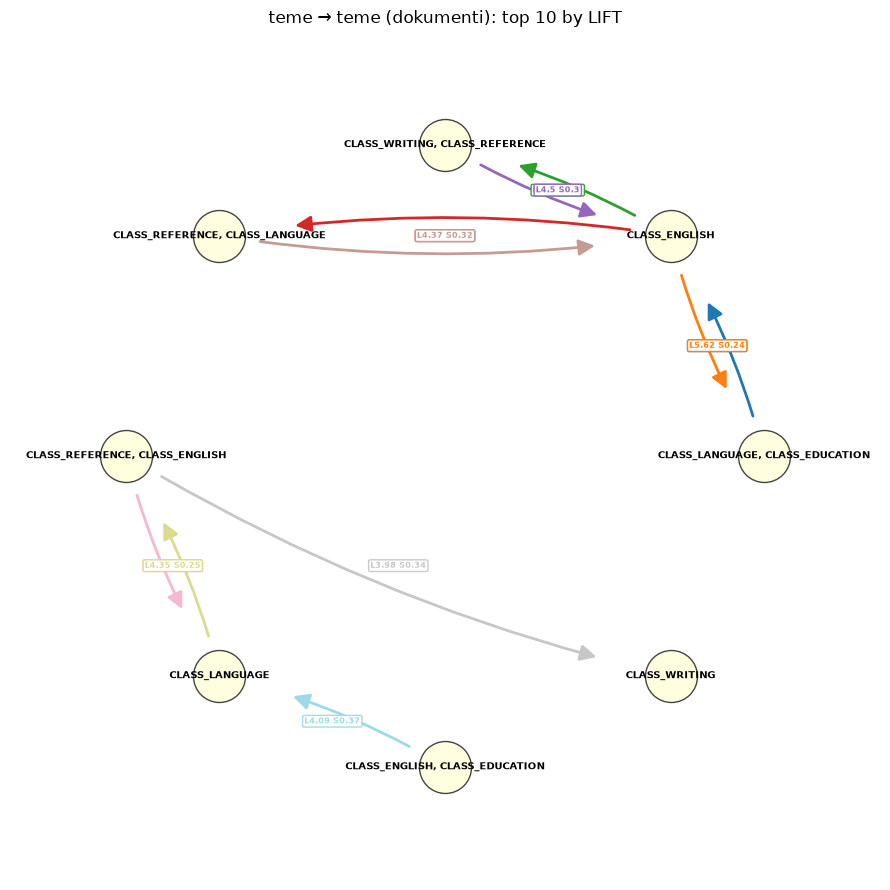

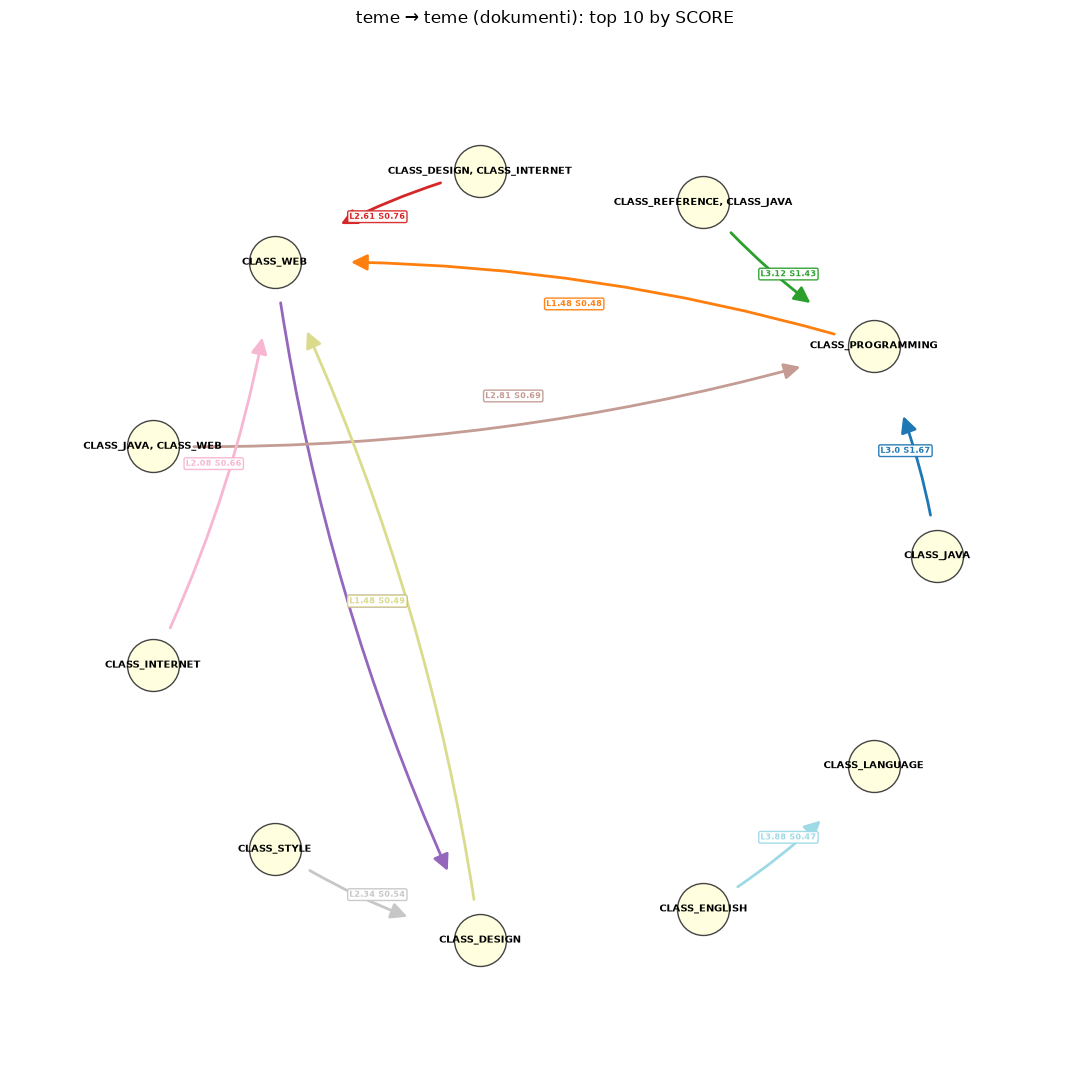

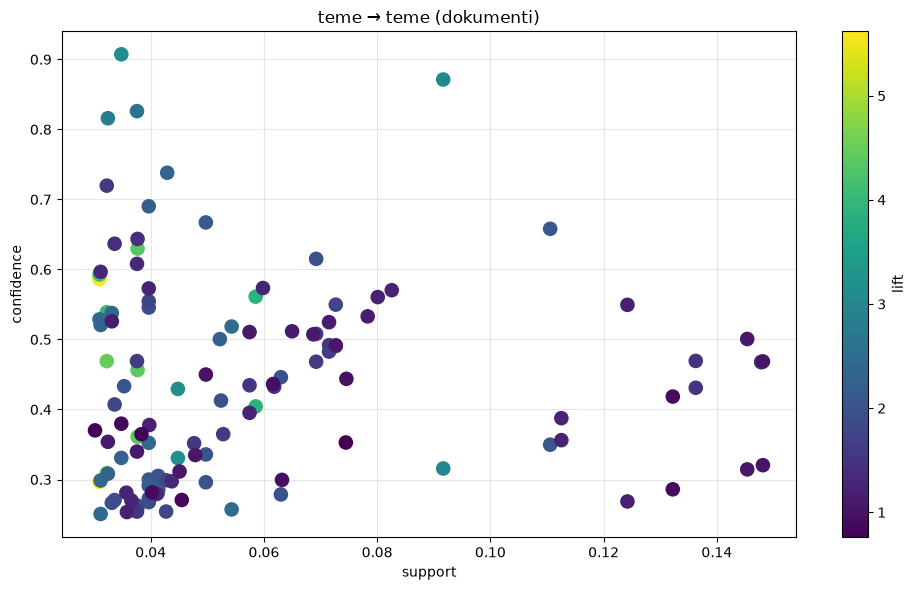

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,score
85,"(CLASS_LANGUAGE, CLASS_EDUCATION)",(CLASS_ENGLISH),0.052809,0.104331,0.030953,0.586142,5.618077,1.0,0.025444,2.164195,0.867832,0.245298,0.537934,0.441412,0.380759
88,(CLASS_ENGLISH),"(CLASS_LANGUAGE, CLASS_EDUCATION)",0.104331,0.052809,0.030953,0.296682,5.618077,1.0,0.025444,1.346748,0.917754,0.245298,0.257471,0.441412,0.236941
90,"(CLASS_WRITING, CLASS_REFERENCE)",(CLASS_ENGLISH),0.068730,0.104331,0.032239,0.469065,4.495908,1.0,0.025068,1.686964,0.834963,0.228933,0.407219,0.389035,0.302898
92,(CLASS_ENGLISH),"(CLASS_WRITING, CLASS_REFERENCE)",0.104331,0.068730,0.032239,0.309005,4.495908,1.0,0.025068,1.347722,0.868151,0.228933,0.258007,0.389035,0.241986
93,"(CLASS_REFERENCE, CLASS_LANGUAGE)",(CLASS_ENGLISH),0.082575,0.104331,0.037678,0.456287,4.373439,1.0,0.029063,1.647320,0.840774,0.252485,0.392953,0.408712,0.319758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,(CLASS_INTERNET),(CLASS_DESIGN),0.168018,0.315961,0.045491,0.270747,0.856901,1.0,-0.007597,0.938000,-0.167167,0.103744,-0.066098,0.207361,0.200061
45,"(CLASS_PROGRAMMING, CLASS_JAVA)",(CLASS_REFERENCE),0.091673,0.462322,0.034810,0.379720,0.821331,1.0,-0.007572,0.866830,-0.193217,0.067048,-0.153628,0.227507,0.161729
111,(CLASS_PHILOSOPHY),(CLASS_REFERENCE),0.081487,0.462322,0.030162,0.370146,0.800623,1.0,-0.007511,0.853654,-0.213292,0.058722,-0.171434,0.217693,0.148256
40,(CLASS_JAVA),(CLASS_REFERENCE),0.105222,0.462322,0.038370,0.364662,0.788761,1.0,-0.010276,0.846286,-0.230357,0.072510,-0.181634,0.223828,0.165773


In [11]:
run_pass(class_transactions, m_drop_self, min_support=0.03,
          min_threshold=0.25, sort_by=("lift",), n=12,
          title="TEME → TEME: kolokacija oznaka (dokumenti)",
          graph="topic_cooccurrence.png",
          graph_title="teme → teme (dokumenti)")

In [12]:
def class_lift_heatmap(co_label_matrix, title, filename, vmin=1.0,
                       vmax=6.0, cmap="magma", fmt=".1f"):
    from scipy.spatial.distance import squareform
    class_probabilities = co_label_matrix.mean(0)
    co_occurrence_rate = (co_label_matrix.T @ co_label_matrix) / len(
        co_label_matrix)
    independence_rate = np.outer(class_probabilities,
                                 class_probabilities)
    with np.errstate(divide="ignore", invalid="ignore"):
        lift = np.where(independence_rate > 0,
                        co_occurrence_rate / independence_rate, 0.0)
    np.fill_diagonal(lift, 1.0)
    counts = co_label_matrix.sum(0)
    class_co_occurrence = co_label_matrix.T @ co_label_matrix
    union = np.add.outer(counts, counts) - class_co_occurrence
    jaccard_distance = 1.0 - class_co_occurrence / np.maximum(
        union, 1)
    np.fill_diagonal(jaccard_distance, 0.0)
    order = dendrogram(linkage(
        squareform(jaccard_distance, checks=False),
        method="average"), no_plot=True)["leaves"]
    fig, ax = plt.subplots(figsize=(10, 9))
    im = ax.imshow(lift[order][:, order], cmap=cmap, aspect="equal",
                   vmin=vmin, vmax=vmax)
    names = [CLASS_NAMES[i] for i in order]
    ax.set_xticks(range(N_CLASSES))
    ax.set_xticklabels(names, rotation=90, fontsize=9)
    ax.set_yticks(range(N_CLASSES))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    shown = lift[order][:, order]
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            value = shown[i, j]
            ax.text(j, i, format(value, fmt), ha="center",
                    va="center", fontsize=5.5,
                    color="white" if value > (vmin + vmax) / 2
                    else "black")
    fig.tight_layout(); show_fig(filename)


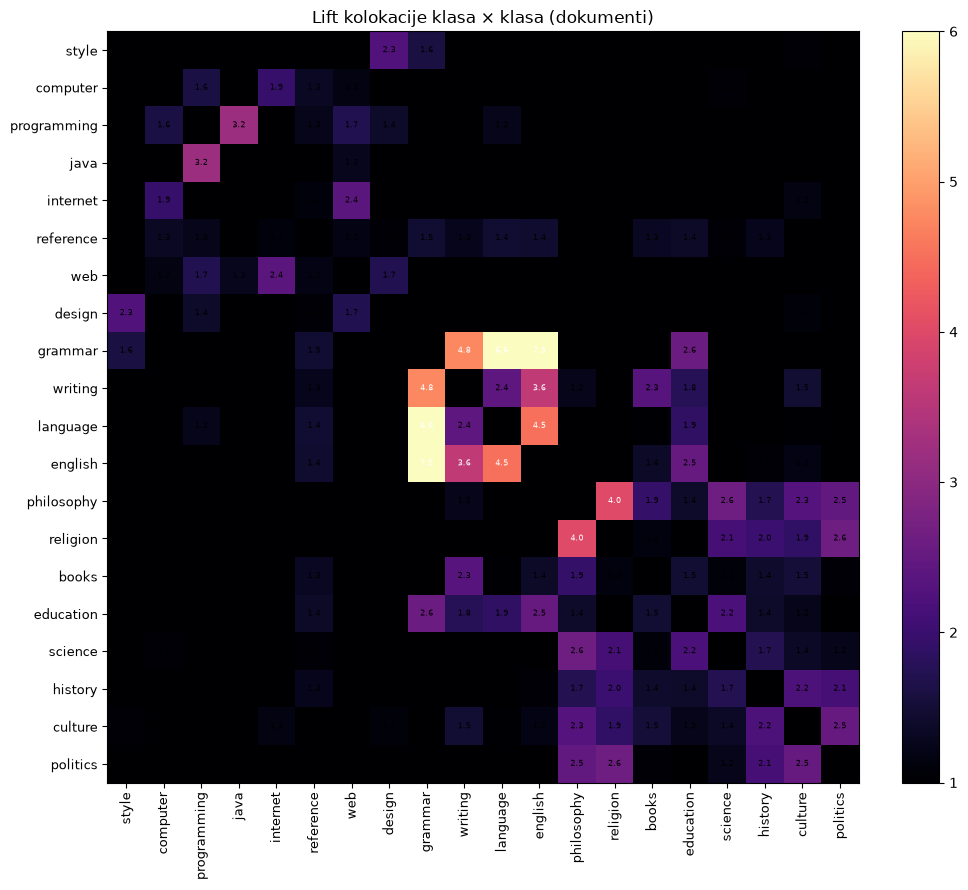

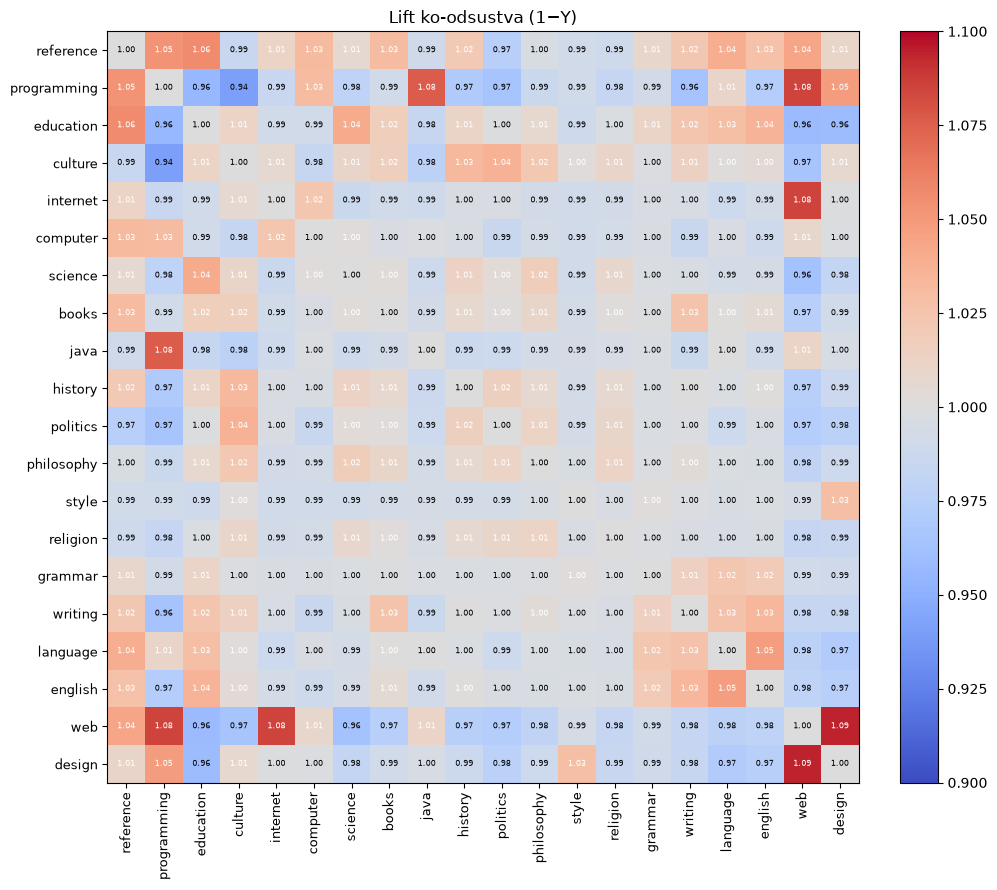

In [13]:
class_lift_heatmap(Y, "Lift kolokacije klasa × klasa (dokumenti)",
                   "class_lift_heatmap.png")
class_lift_heatmap(1 - Y, "Lift ko-odsustva (1−Y)",
                   "class_NEG_lift_heatmap.png",
                   vmin=0.9, vmax=1.1, cmap="coolwarm", fmt=".2f")

## 3. Reči → teme


REČI → TEME (dokumenti)
       antecedents         consequents  support  confidence     lift  leverage  conviction    score
   (class, object) (CLASS_PROGRAMMING) 0.003270    0.952381 3.849167  0.002420   15.804071 0.903680
(teacher, student)   (CLASS_EDUCATION) 0.003351    0.931818 4.826361  0.002657   11.834995 0.685134
   (class, method) (CLASS_PROGRAMMING) 0.004087    0.892857 3.608594  0.002954    7.024031 0.449042
  (method, object) (CLASS_PROGRAMMING) 0.003270    0.888889 3.592556  0.002359    6.773173 0.387291
      (rubi, rail) (CLASS_PROGRAMMING) 0.003842    0.839286 3.392078  0.002709    4.682688 0.290242
   (length, frame)   (CLASS_EDUCATION) 0.005150    0.470149 2.435142  0.003035    1.522941 0.109287
  (parent, length)   (CLASS_EDUCATION) 0.005068    0.466165 2.414508  0.002969    1.511576 0.107607
 (polici, privaci)   (CLASS_REFERENCE) 0.003842    0.447619 1.155554  0.000517    1.109084 0.068743
  (substr, length)   (CLASS_EDUCATION) 0.005395    0.428571 2.219790  0.002

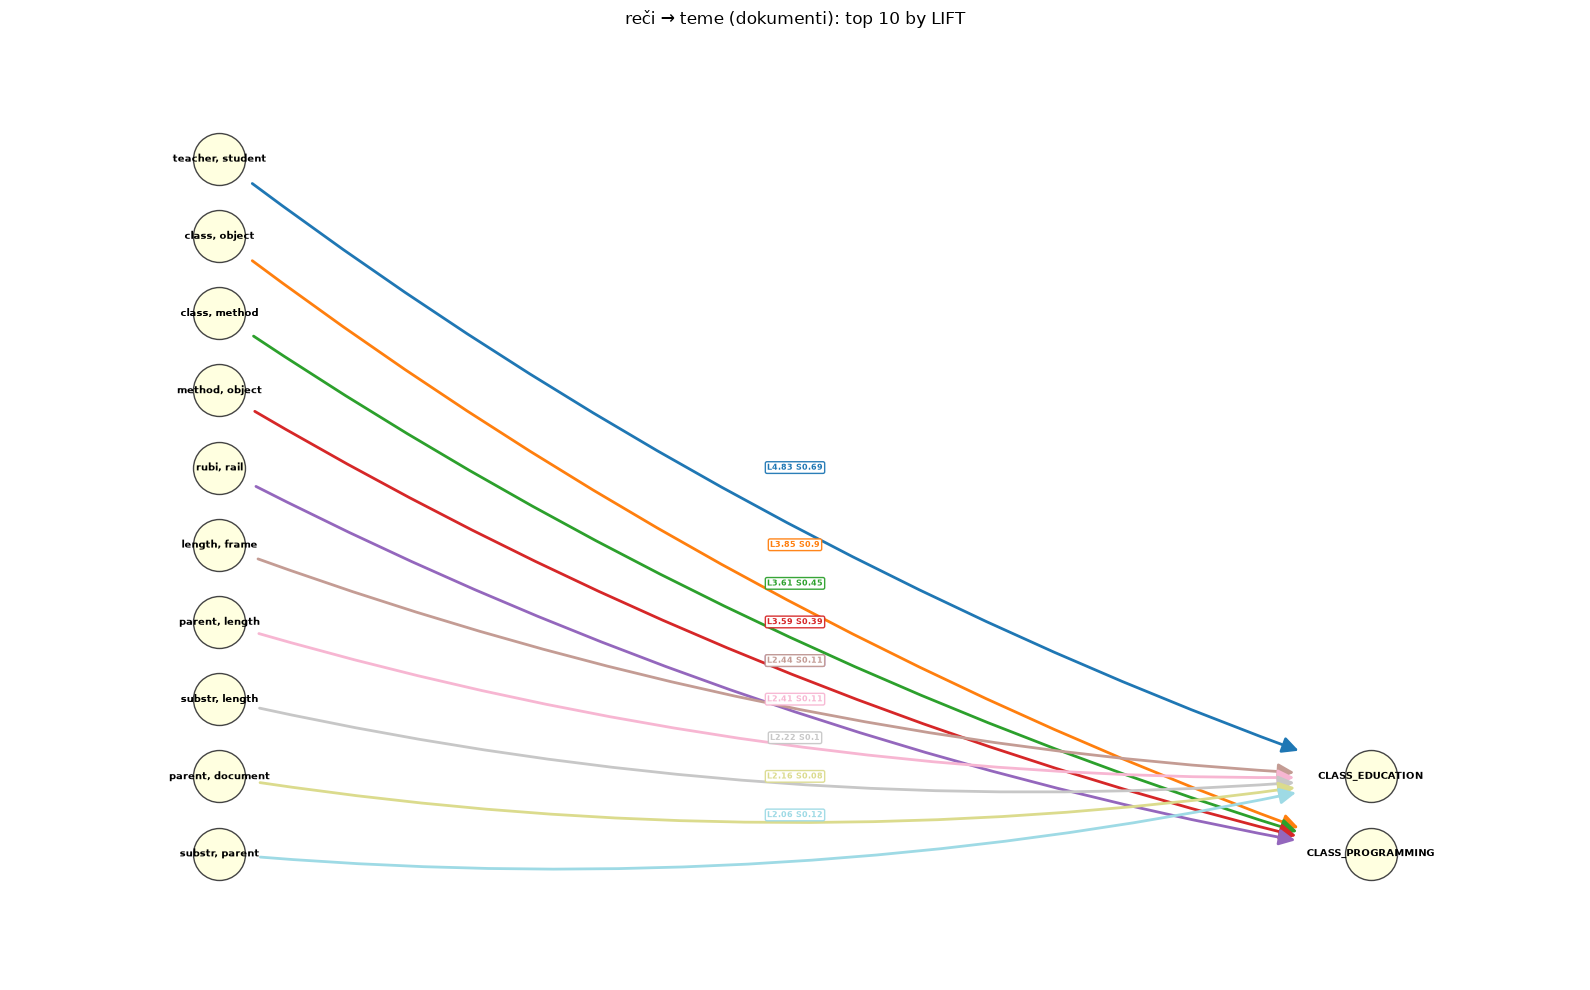

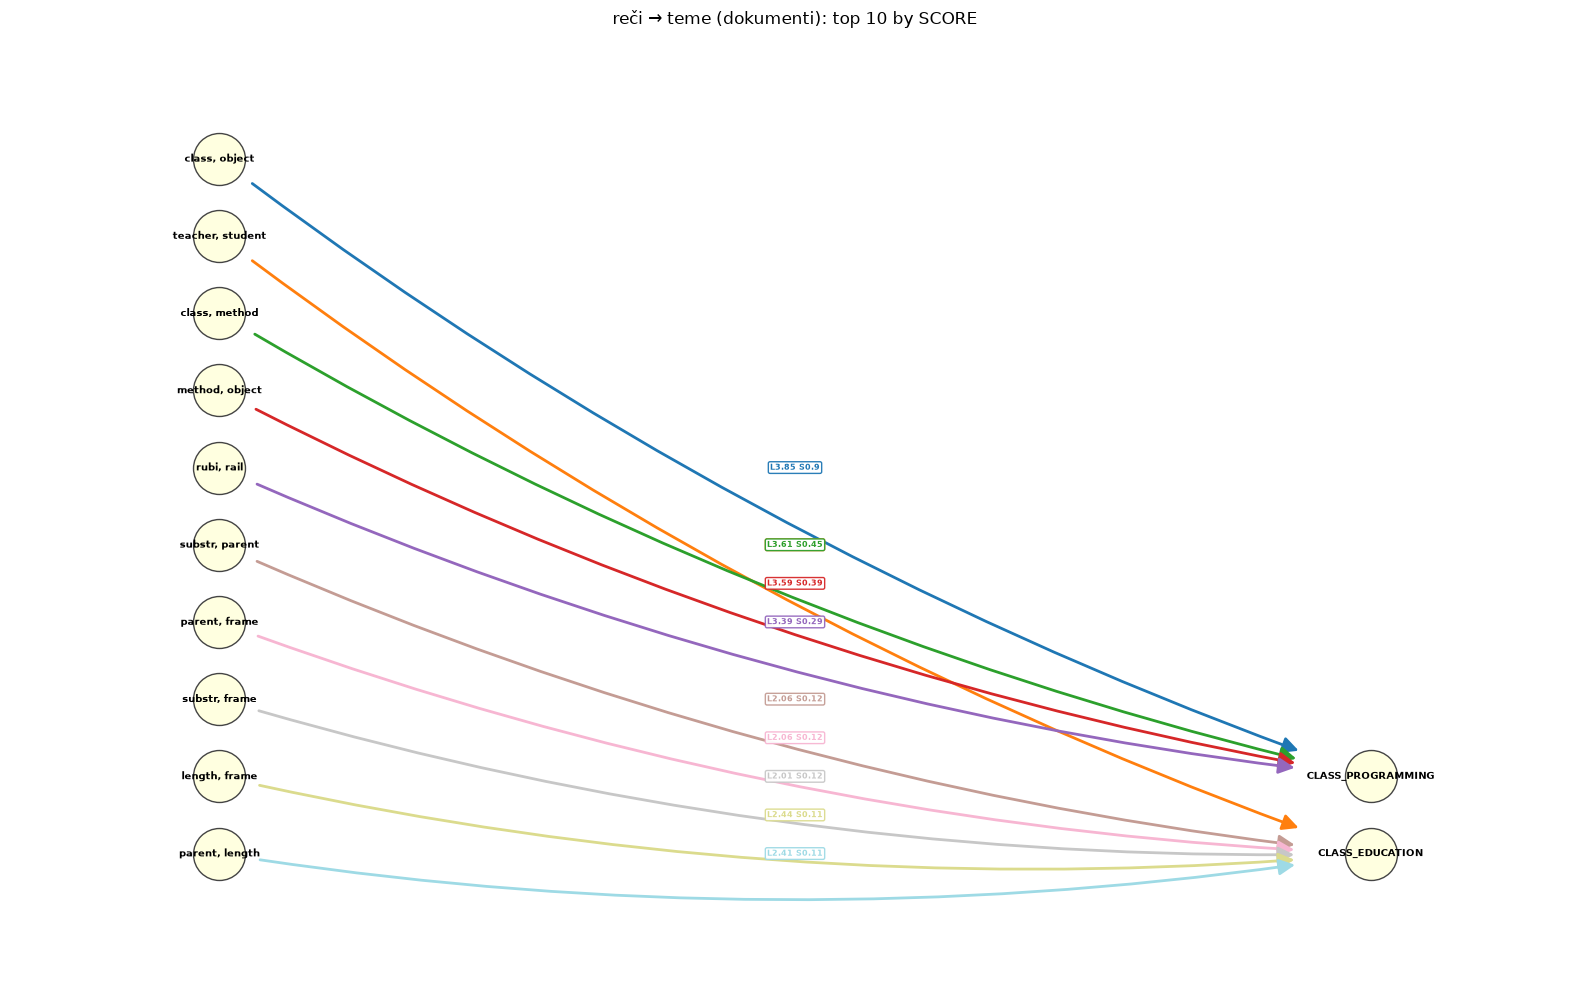

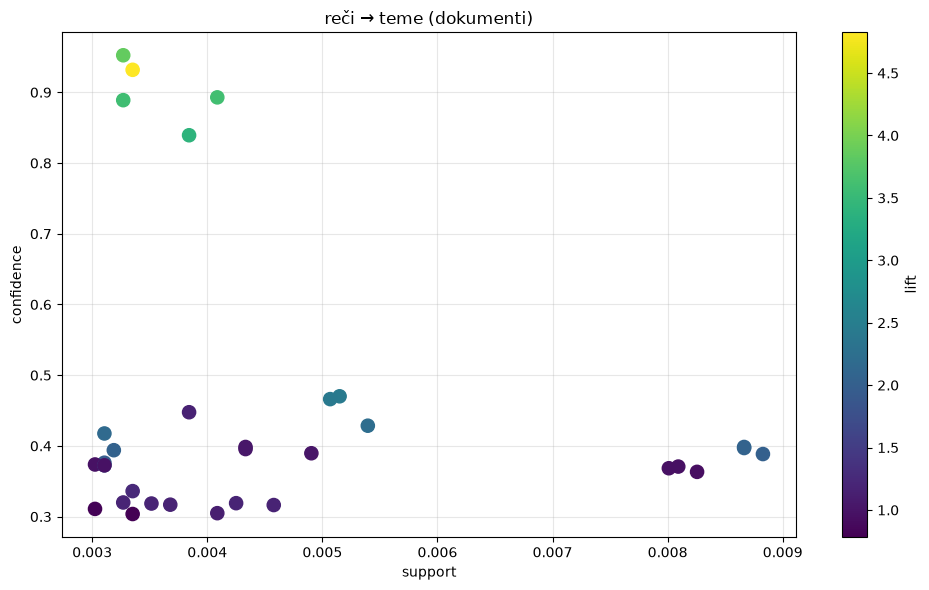

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,score
1037,"(class, object)",(CLASS_PROGRAMMING),0.003433,0.247425,0.003270,0.952381,3.849167,1.0,0.002420,15.804071,0.742753,0.013206,0.936725,0.482798,0.903680
2223,"(teacher, student)",(CLASS_EDUCATION),0.003597,0.193068,0.003351,0.931818,4.826361,1.0,0.002657,11.834995,0.795666,0.017336,0.915505,0.474588,0.685134
1248,"(class, method)",(CLASS_PROGRAMMING),0.004577,0.247425,0.004087,0.892857,3.608594,1.0,0.002954,7.024031,0.726208,0.016485,0.857632,0.454688,0.449042
1252,"(method, object)",(CLASS_PROGRAMMING),0.003678,0.247425,0.003270,0.888889,3.592556,1.0,0.002359,6.773173,0.724311,0.013193,0.852359,0.451052,0.387291
113,"(rubi, rail)",(CLASS_PROGRAMMING),0.004577,0.247425,0.003842,0.839286,3.392078,1.0,0.002709,4.682688,0.708438,0.015481,0.786447,0.427406,0.290242
549,"(length, frame)",(CLASS_EDUCATION),0.010953,0.193068,0.005150,0.470149,2.435142,1.0,0.003035,1.522941,0.595873,0.025894,0.343376,0.248411,0.109287
553,"(parent, length)",(CLASS_EDUCATION),0.010871,0.193068,0.005068,0.466165,2.414508,1.0,0.002969,1.511576,0.592276,0.025483,0.338439,0.246207,0.107607
2012,"(polici, privaci)",(CLASS_REFERENCE),0.008583,0.387363,0.003842,0.447619,1.155554,1.0,0.000517,1.109084,0.135780,0.009798,0.098355,0.228768,0.068743
545,"(substr, length)",(CLASS_EDUCATION),0.012588,0.193068,0.005395,0.428571,2.219790,1.0,0.002964,1.412130,0.556512,0.026939,0.291850,0.228257,0.103720
694,"(parent, document)",(CLASS_EDUCATION),0.007438,0.193068,0.003106,0.417582,2.162872,1.0,0.001670,1.385486,0.541681,0.015735,0.278232,0.216835,0.077216


In [14]:
run_pass(word_transactions, m_words_class,
          min_support=0.003, min_threshold=0.3, max_len=3, n=15,
          title="REČI → TEME (dokumenti)",
          csv="csv/words_to_topics.csv",
          graph="words_to_topics.png",
          graph_title="reči → teme (dokumenti)")

## 4. Teme → reči (potpisi)


TEME → REČI: potpisi tema
                    antecedents     consequents  support  confidence     lift  leverage  conviction    score
(CLASS_PROGRAMMING, CLASS_JAVA)     (implement) 0.020598    0.271845 4.172833  0.015662    1.283866 0.184262
                   (CLASS_JAVA)     (implement) 0.024440    0.255337 3.919444  0.018204    1.255406 0.196262
            (CLASS_PROGRAMMING)  (exampl, code) 0.039071    0.157912 3.263339  0.027099    1.130061 0.223373
(CLASS_PROGRAMMING, CLASS_JAVA)        (applic) 0.027873    0.367853 3.249326  0.019295    1.402825 0.234205
            (CLASS_PROGRAMMING) (develop, code) 0.038499    0.155600 3.226450  0.026567    1.127159 0.221163
(CLASS_PROGRAMMING, CLASS_JAVA)        (object) 0.021579    0.284790 3.202313  0.014841    1.273846 0.187126
                   (CLASS_JAVA)        (applic) 0.034658    0.362084 3.198362  0.023821    1.390137 0.258795
(CLASS_PROGRAMMING, CLASS_JAVA)         (class) 0.020517    0.270766 3.172941  0.014050    1.254280 0

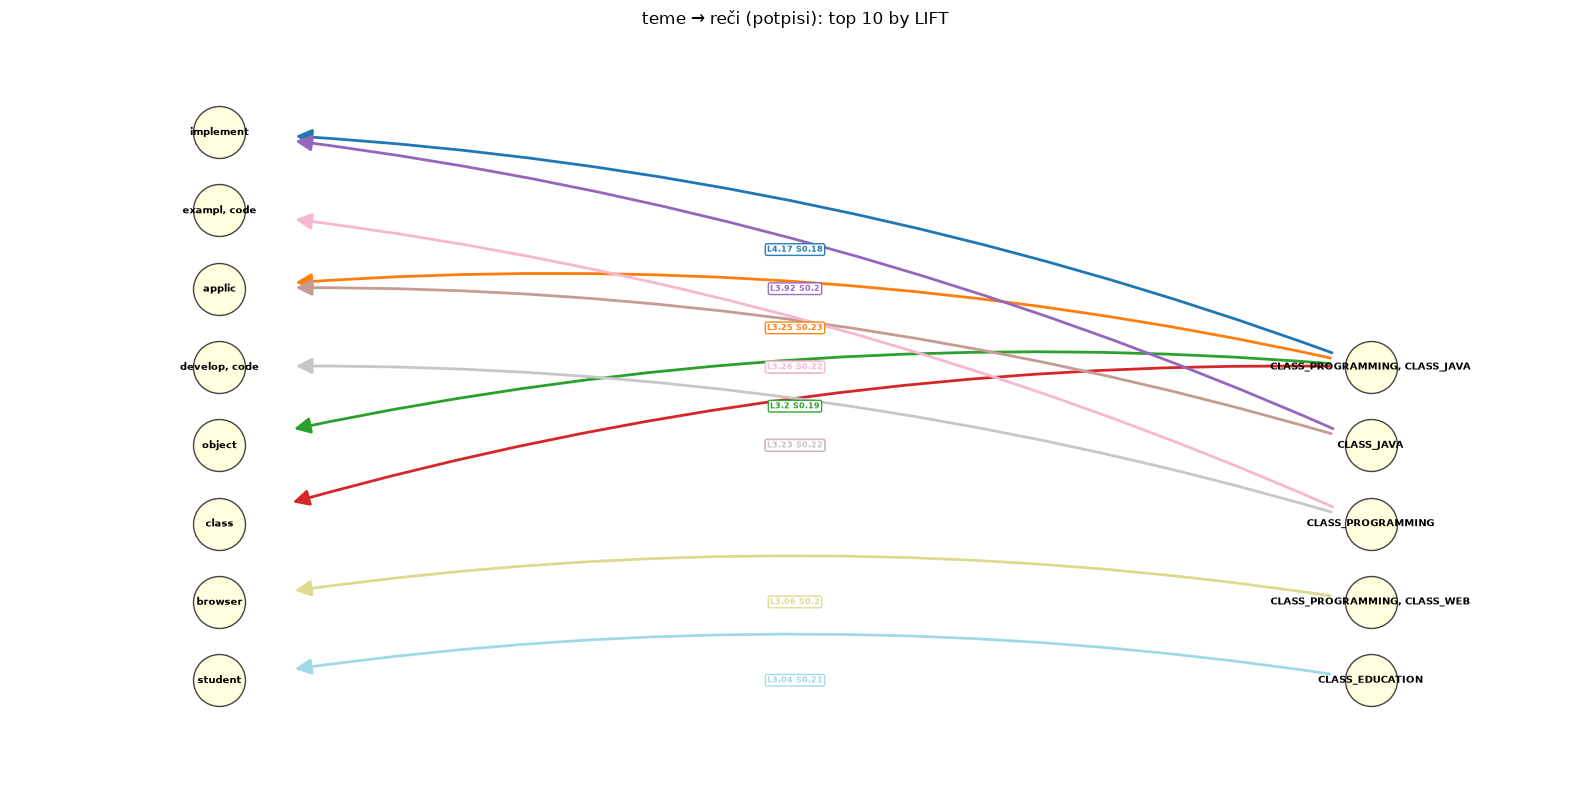

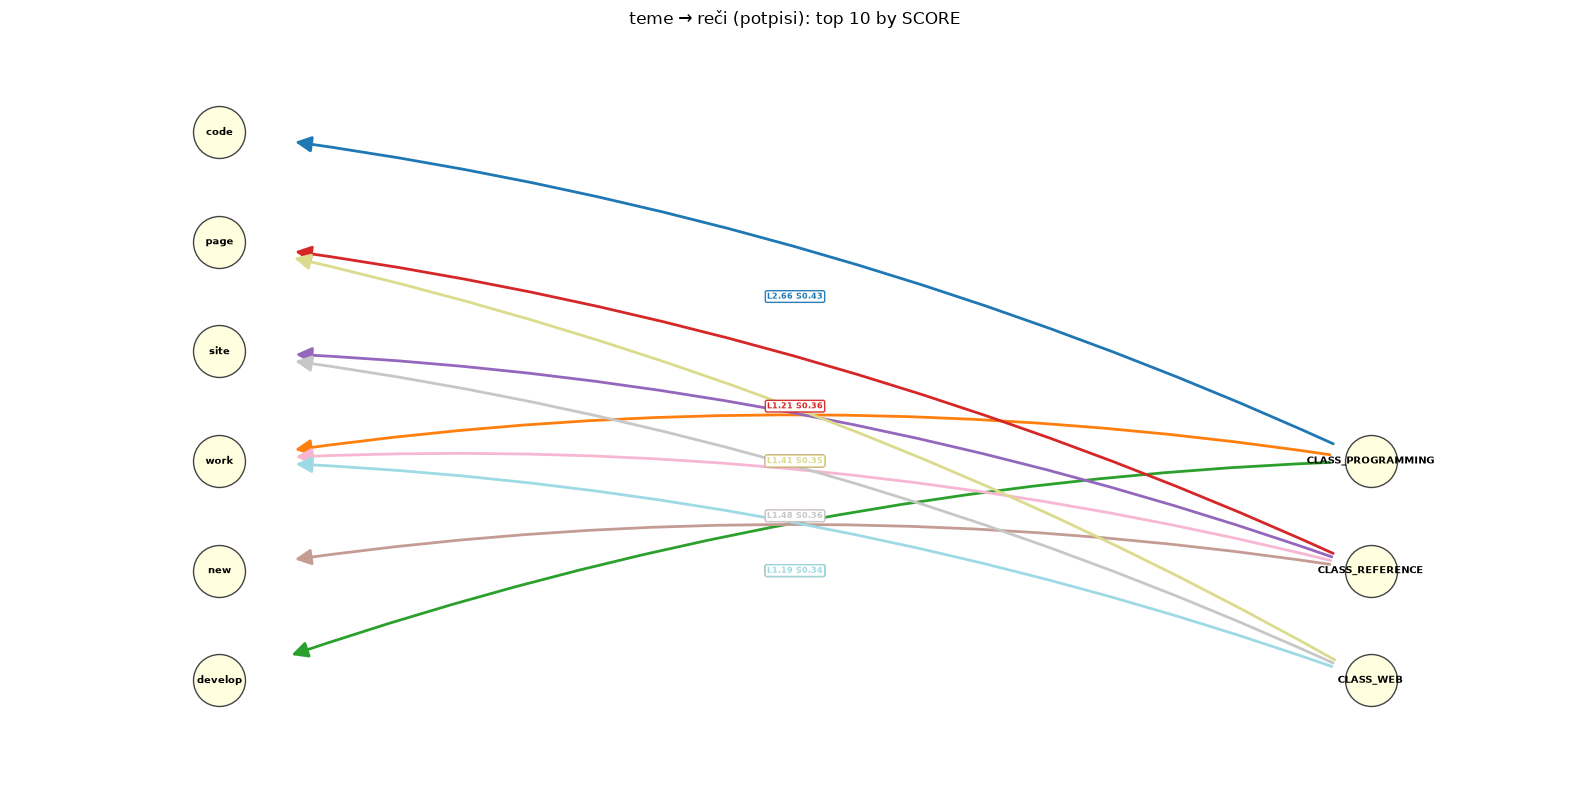

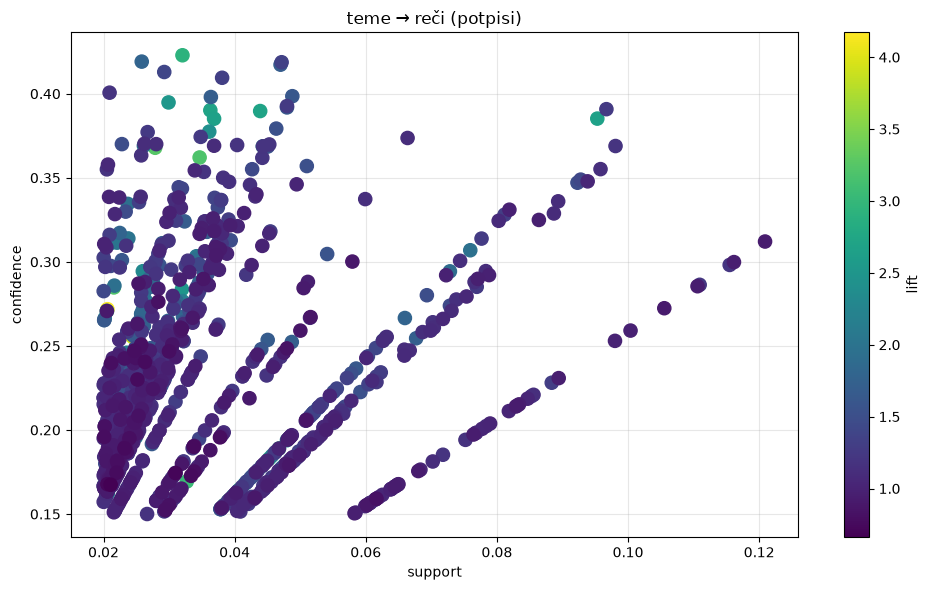

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,score
11897,"(CLASS_PROGRAMMING, CLASS_JAVA)",(implement),0.075772,0.065146,0.020598,0.271845,4.172833,1.0,0.015662,1.283866,0.822692,0.171196,0.221102,0.294015,0.184262
11866,(CLASS_JAVA),(implement),0.095717,0.065146,0.024440,0.255337,3.919444,1.0,0.018204,1.255406,0.823704,0.179149,0.203445,0.315247,0.196262
9050,(CLASS_PROGRAMMING),"(exampl, code)",0.247425,0.048390,0.039071,0.157912,3.263339,1.0,0.027099,1.130061,0.921590,0.152181,0.115092,0.482672,0.223373
445,"(CLASS_PROGRAMMING, CLASS_JAVA)",(applic),0.075772,0.113209,0.027873,0.367853,3.249326,1.0,0.019295,1.402825,0.748997,0.173009,0.287152,0.307031,0.234205
8868,(CLASS_PROGRAMMING),"(develop, code)",0.247425,0.048226,0.038499,0.155600,3.226450,1.0,0.026567,1.127159,0.916935,0.149714,0.112814,0.476952,0.221163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1883,(CLASS_CULTURE),(need),0.177620,0.252411,0.033758,0.190060,0.752977,1.0,-0.011075,0.923017,-0.285162,0.085190,-0.083403,0.161902,0.169590
13658,(CLASS_SCIENCE),(need),0.122773,0.252411,0.023214,0.189081,0.749100,1.0,-0.007775,0.921903,-0.276313,0.065954,-0.084712,0.140525,0.140462
13666,(CLASS_SCIENCE),(look),0.122773,0.229279,0.020598,0.167776,0.731756,1.0,-0.007551,0.926098,-0.294722,0.062145,-0.079799,0.128808,0.132915
1868,(CLASS_CULTURE),(page),0.177620,0.246853,0.030979,0.174413,0.706547,1.0,-0.012867,0.912257,-0.335565,0.078729,-0.096183,0.149955,0.160566


In [15]:
run_pass(topk_word_class_transactions(term_matrix, Y, terms, top_k=None),
          m_class_words, min_support=0.02, min_threshold=0.15,
          max_len=3, sort_by=("lift", "confidence"), n=12,
          title="TEME → REČI: potpisi tema",
          csv="csv/topic_signatures.csv",
          graph="topic_signatures.png",
          graph_title="teme → reči (potpisi)")

## 5. Reč → reč


REČ → REČ (dokumenti, lift≥2)
     antecedents      consequents  support  confidence      lift  leverage  conviction     score
  (text, script)           (type) 0.012915    0.969325 45.610477  0.012632   31.907177  3.626041
          (type)   (text, script) 0.012915    0.607692 45.610477  0.012632    2.515058  0.285820
          (text)   (type, script) 0.012915    0.587361 40.597568  0.012597    2.388362  0.271422
  (type, script)           (text) 0.012915    0.892655 40.597568  0.012597    9.110955  1.035400
 (length, frame)         (parent) 0.010871    0.992537 37.710253  0.010583  130.473108 13.603874
        (parent)  (length, frame) 0.010871    0.413043 37.710253  0.010583    1.685043  0.175692
 (substr, frame)         (parent) 0.021743    0.956835 36.353769  0.021145   22.556918  3.326108
        (parent)  (substr, frame) 0.021743    0.826087 36.353769  0.021145    5.619340  0.828594
        (substr) (parent, length) 0.010871    0.383285 35.256484  0.010563    1.603867  0.167228

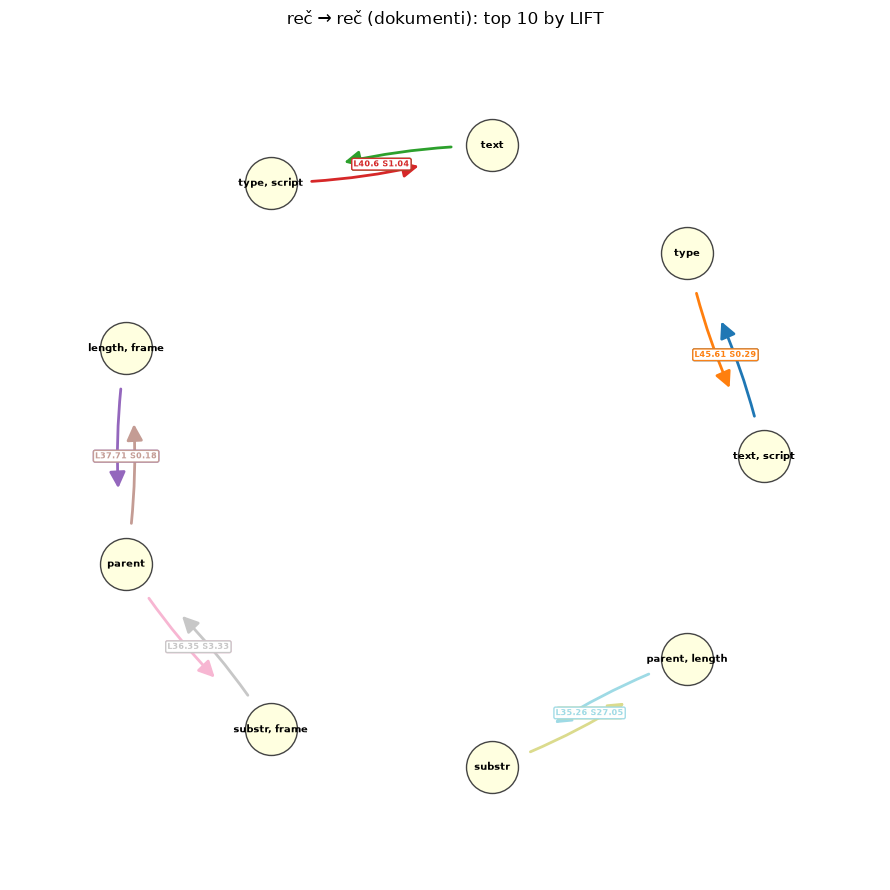

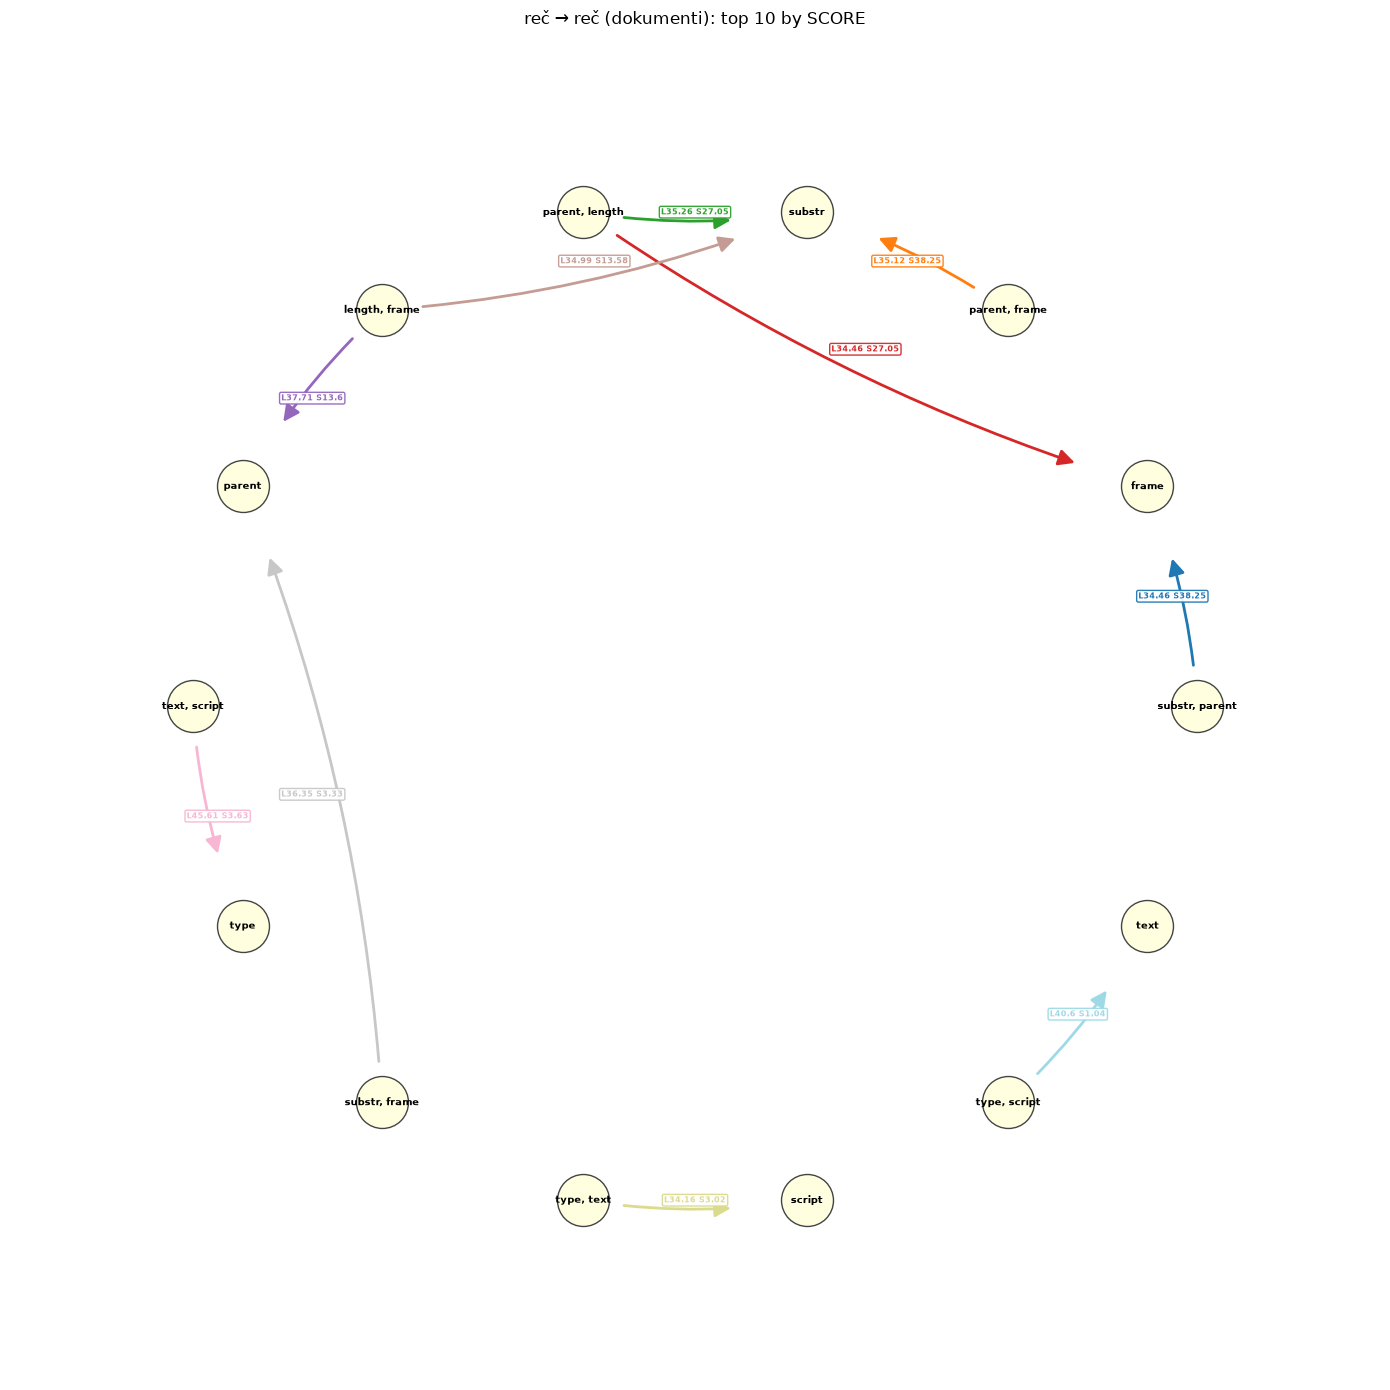

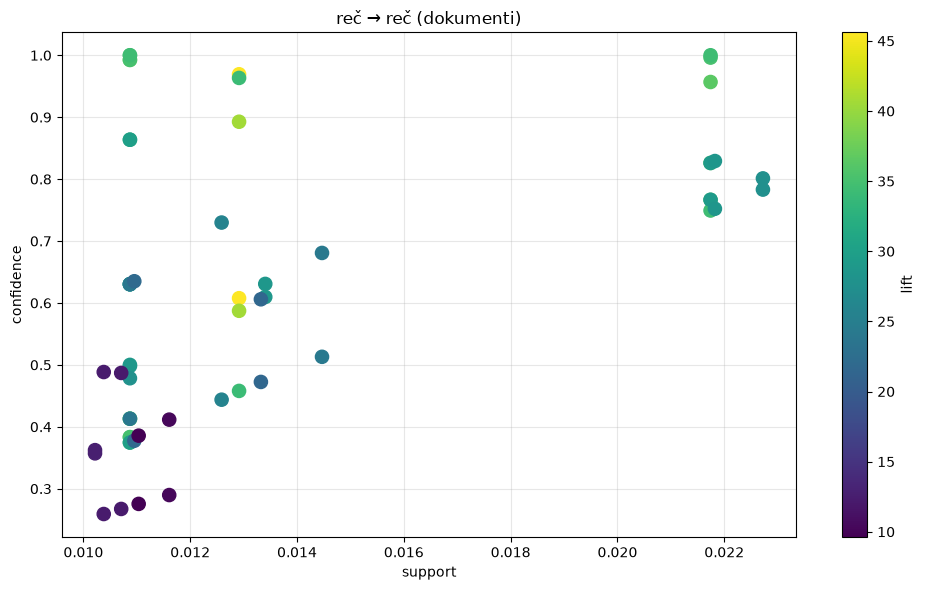

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,score
54,"(text, script)",(type),0.013324,0.021252,0.012915,0.969325,45.610477,1.0,0.012632,31.907177,0.991283,0.596226,0.968659,0.788509,3.626041
55,(type),"(text, script)",0.021252,0.013324,0.012915,0.607692,45.610477,1.0,0.012632,2.515058,0.999313,0.596226,0.602395,0.788509,0.285820
56,(text),"(type, script)",0.021988,0.014468,0.012915,0.587361,40.597568,1.0,0.012597,2.388362,0.997296,0.548611,0.581303,0.740008,0.271422
53,"(type, script)",(text),0.014468,0.021988,0.012915,0.892655,40.597568,1.0,0.012597,9.110955,0.989687,0.548611,0.890242,0.740008,1.035400
20,"(length, frame)",(parent),0.010953,0.026320,0.010871,0.992537,37.710253,1.0,0.010583,130.473108,0.984263,0.411765,0.992336,0.702790,13.603874
21,(parent),"(length, frame)",0.026320,0.010953,0.010871,0.413043,37.710253,1.0,0.010583,1.685043,0.999797,0.411765,0.406543,0.702790,0.175692
35,"(substr, frame)",(parent),0.022724,0.026320,0.021743,0.956835,36.353769,1.0,0.021145,22.556918,0.995105,0.796407,0.955668,0.891461,3.326108
38,(parent),"(substr, frame)",0.026320,0.022724,0.021743,0.826087,36.353769,1.0,0.021145,5.619340,0.998781,0.796407,0.822043,0.891461,0.828594
27,(substr),"(parent, length)",0.028364,0.010871,0.010871,0.383285,35.256484,1.0,0.010563,1.603867,1.000000,0.383285,0.376507,0.691643,0.167228
26,"(parent, length)",(substr),0.010871,0.028364,0.010871,1.000000,35.256484,1.0,0.010563,inf,0.982316,0.383285,1.000000,0.691643,27.049337


In [16]:
run_pass(strip_classes(word_transactions), m_words_words,
          min_support=0.01, metric="lift", min_threshold=2.0,
          max_len=3, sort_by=("lift", "confidence"), n=12,
          title="REČ → REČ (dokumenti, lift≥2)",
          csv="csv/word_pairs.csv",
          graph="word_pairs.png",
          graph_title="reč → reč (dokumenti)")

## 6. Sekvencijalna pravila: redosled reči u rečenici


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

MIN_DF = 50


def zhang(p_ab, p_a, p_b):
    numerator = p_ab - p_a * p_b
    denominator = max(p_ab * (1 - p_a), p_a * (1 - p_ab))
    return numerator / denominator if denominator > 0 else 0.0


def j_measure(p_a, p_b, confidence):
    true_part = confidence * np.log2(max(confidence, 1e-12)
                                     / max(p_b, 1e-12))
    false_part = (1 - confidence) * np.log2(
        max(1 - confidence, 1e-12) / max(1 - p_b, 1e-12))
    return p_a * (true_part + false_part)


def mine_ordered_class_rules(document_words, Y, min_df=MIN_DF,
                             window=8):
    def adjacent(doc):
        return [" ".join(sentence[i:i + 2])
                for sentence in doc for i in range(len(sentence) - 1)]

    def unordered(doc):
        out = set()
        for sentence in doc:
            for i in range(len(sentence)):
                for j in range(i + 1, min(len(sentence), i + window)):
                    out.add(" ".join(sorted((sentence[i], sentence[j]))))
        return list(out)

    adjacent_vectorizer = CountVectorizer(analyzer=adjacent,
                                          min_df=min_df, binary=True)
    unordered_vectorizer = CountVectorizer(analyzer=unordered,
                                           min_df=min_df, binary=True)
    adjacent_matrix = adjacent_vectorizer.fit_transform(document_words)
    unordered_matrix = unordered_vectorizer.fit_transform(document_words)
    number_of_documents = Y.shape[0]
    class_base_rates = Y.mean(0)
    adjacent_frequencies = np.asarray(adjacent_matrix.sum(0)).ravel()
    adjacent_class_counts = np.asarray(adjacent_matrix.T @ Y)
    unordered_frequencies = np.asarray(unordered_matrix.sum(0)).ravel()
    unordered_class_counts = np.asarray(unordered_matrix.T @ Y)
    unordered_index = {w: i for i, w in
                       enumerate(unordered_vectorizer
                                 .get_feature_names_out())}
    rows = []
    for word_index, pair in enumerate(
            adjacent_vectorizer.get_feature_names_out()):
        if any(token in CLASS_WORD_STOPLIST for token in pair.split()):
            continue
        for c in range(N_CLASSES):
            pair_class_count = adjacent_class_counts[word_index, c]
            if pair_class_count < 3:
                continue
            confidence = pair_class_count / adjacent_frequencies[word_index]
            lift = confidence / class_base_rates[c]
            if lift < 2.0:
                continue
            p_a = adjacent_frequencies[word_index] / number_of_documents
            p_b = class_base_rates[c]
            p_ab = pair_class_count / number_of_documents
            bonus = None
            key = " ".join(sorted(pair.split()))
            if (key in unordered_index
                    and unordered_frequencies[unordered_index[key]]
                    >= min_df):
                unordered_confidence = (
                    unordered_class_counts[unordered_index[key], c]
                    / unordered_frequencies[unordered_index[key]])
                bonus = (confidence / unordered_confidence
                         if unordered_confidence > 0 else np.inf)
            rows.append(dict(
                pair=pair, cls=CLASS_NAMES[c],
                support=round(p_ab, 5), confidence=round(confidence, 3),
                lift=round(lift, 1),
                zhang=round(zhang(p_ab, p_a, p_b), 3),
                j_bits=round(j_measure(p_a, p_b, confidence), 4),
                order_bonus=(round(bonus, 2)
                             if bonus is not None else None)))
    return pd.DataFrame(rows)


def sentence_order_rules(vocab):
    document_words = []
    for path in ("train-data.dat", "test-data.dat"):
        for sents in parse_sentences(path):
            document_words.append(
                [[vocab.get(w, "?") for w in sentence]
                 for sentence in sents])
    Y = np.vstack([
        pd.read_csv("train-label.dat", sep=" ", header=None).values,
        pd.read_csv("test-label.dat", sep=" ", header=None).values])
    log("uređeni parovi: CountVectorizer (susedni + prozor 8) nad 12 234 dokumenata ...")
    rules = cached(
        "ordered_rules.pkl",
        lambda: mine_ordered_class_rules(document_words, Y)
        .sort_values(["lift", "confidence"], ascending=False))
    print("\n" + "=" * 72)
    print(f"UREĐENI PAROVI REČI → KLASA (susedne reči, df>={MIN_DF}, "
          "lift>=2, count>=3)")
    print("=" * 72)
    with pd.option_context("display.width", 150):
        print(rules.head(20).to_string(index=False))
    rules.to_csv("csv/ordered_class_rules.csv", index=False)
    print("\nNajveći ORDER BONUS — gde SAMO REDOSLED dodaje na "
          "ko-okurenciju:")
    with_bonus = rules[rules.order_bonus.notna()]
    with pd.option_context("display.width", 150):
        print(with_bonus.sort_values("order_bonus",
                                     ascending=False).head(12)
              .to_string(index=False))
    print("\nNajviše J-bita (koliko informacije par nosi o klasi):")
    with pd.option_context("display.width", 150):
        print(rules.sort_values("j_bits", ascending=False).head(10)
              .to_string(index=False))
    if not rules.empty:
        fig, ax = plt.subplots(figsize=(10, 6))
        sc = ax.scatter(rules.support, rules.confidence, c=rules.lift,
                        cmap="viridis", s=90, zorder=3)
        plt.colorbar(sc, ax=ax, label="lift")
        ax.set_xlabel("support"); ax.set_ylabel("confidence")
        ax.set_title("Uređeni parovi reči → klasa (boja = lift)")
        ax.grid(True, alpha=0.3)
        fig.tight_layout(); show_fig("ordered_class_rules_scatter.png")
    return rules

[22:06:03] uređeni parovi: CountVectorizer (susedni + prozor 8) nad 12 234 dokumenata ...
  [keš] ordered_rules.pkl učitan (obriši za ponovni račun)

UREĐENI PAROVI REČI → KLASA (susedne reči, df>=50, lift>=2, count>=3)
          pair        cls  support  confidence  lift  zhang  j_bits  order_bonus
   word phrase    grammar  0.00114       0.250   8.6  0.221  0.0023         0.99
   word phrase    english  0.00262       0.571   6.5  0.484  0.0049         1.07
applic develop       java  0.00245       0.600   6.3  0.506  0.0046         1.07
    applic use       java  0.00409       0.581   6.1  0.488  0.0074         1.37
      use word    grammar  0.00106       0.171   5.9  0.142  0.0015         1.09
     unit test       java  0.00237       0.527   5.5  0.433  0.0038         1.05
 improv articl philosophy  0.00163       0.377   5.3  0.307  0.0024         1.11
       don use    grammar  0.00090       0.149   5.1  0.120  0.0011         2.11
    hard drive   computer  0.00351       0.642   5.

C:\Users\Trile\PycharmProjects\PythonProject3\.venv\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape
C:\Users\Trile\PycharmProjects\PythonProject3\.venv\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


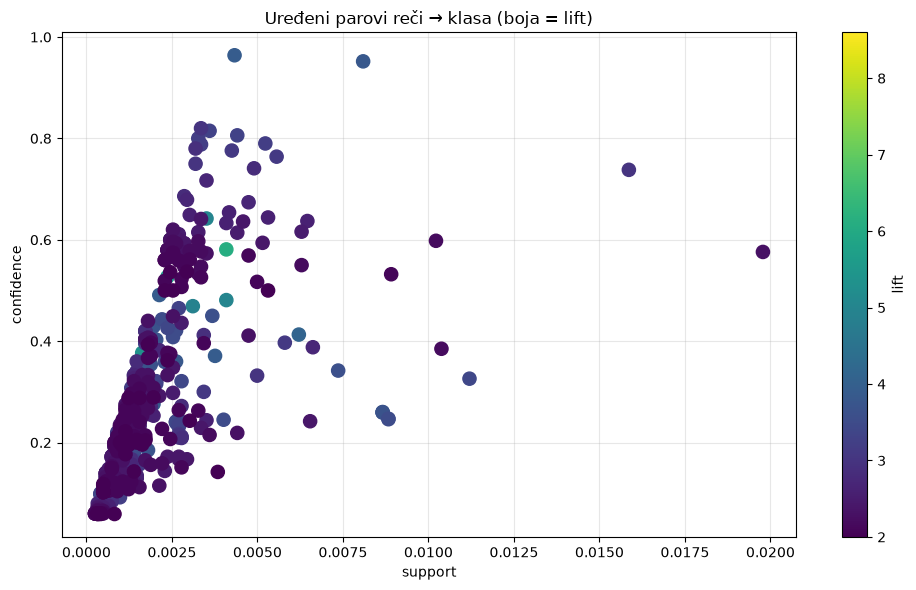

,pair,cls,support,confidence,lift,zhang,j_bits,order_bonus
528,word phrase,grammar,0.00114,0.250,8.6,0.221,0.0023,0.99
527,word phrase,english,0.00262,0.571,6.5,0.484,0.0049,1.07
16,applic develop,java,0.00245,0.600,6.3,0.506,0.0046,1.07
19,applic use,java,0.00409,0.581,6.1,0.488,0.0074,1.37
480,use word,grammar,0.00106,0.171,5.9,0.142,0.0015,1.09
...,...,...,...,...,...,...,...,...
408,site map,grammar,0.00041,0.060,2.0,0.030,0.0001,1.15
14,amazon com,grammar,0.00033,0.059,2.0,0.030,0.0001,1.04
94,differ between,grammar,0.00082,0.059,2.0,0.030,0.0002,1.23
453,tri out,grammar,0.00041,0.059,2.0,0.030,0.0001,1.63


In [18]:
sentence_order_rules(vocab)

## 7. Privlačenja i odbijanja reč–tema (ceo vokabular)


In [19]:
def word_class_lifts(term_matrix, terms, Y, *, min_df=150,
                      attract_lift=5.0, home_lift_min=3.0,
                      cross_domain=True):
    presence_matrix = (term_matrix > 0).astype(np.float32)
    document_frequencies = np.asarray(
        presence_matrix.sum(axis=0)).ravel()
    keep = document_frequencies >= min_df
    frequent_terms = terms[keep]
    word_class_counts = np.asarray(
        presence_matrix.T.dot(Y.astype(np.float32)))[keep]
    class_base_rates = Y.mean(0)
    word_class_lifts = (word_class_counts
                        / document_frequencies[keep][:, None]) \
        / class_base_rates[None, :]
    print("\n" + "=" * 72)
    print(f"REČ ↔ TEMA: lift P(c|w)/P(c), ceo vokabular "
          f"(df>={min_df}; prikazani parovi sa liftom >= {attract_lift})")
    print("=" * 72)
    attraction_rows = [
        (word_class_lifts[w, c], frequent_terms[w], CLASS_NAMES[c],
         word_class_counts[w, c] / document_frequencies[keep][w],
         class_base_rates[c])
        for w in range(len(frequent_terms))
        for c in range(N_CLASSES)
        if word_class_lifts[w, c] >= attract_lift]
    attraction_rows.sort(reverse=True)
    for (lift_value, word, class_name, p_class_given_word,
         p_class_prior) in attraction_rows[:12]:
        print(f"  {word:<12}{class_name:<14}lift {lift_value:>5.1f}"
              f"  P(c|w) {p_class_given_word:.3f}  "
              f"P(c) {p_class_prior:.3f}")
    if cross_domain:
        home_class = np.argmax(word_class_lifts, axis=1)
        home_lift = word_class_lifts[
            np.arange(len(frequent_terms)), home_class]
        repulsions = []
        for word_index in np.where(home_lift
                                   >= home_lift_min)[0]:
            for c in range(N_CLASSES):
                if (c != home_class[word_index]
                        and class_base_rates[c] >= 0.08
                        and word_class_lifts[word_index, c] < 0.5):
                    repulsions.append(
                        (word_class_lifts[word_index, c],
                         frequent_terms[word_index],
                         CLASS_NAMES[home_class[word_index]],
                         CLASS_NAMES[c]))
        repulsions.sort()
        print(f"  Parovi sa liftom < 0.5 (reči sa domenskim "
              f"liftom >= {home_lift_min}):")
        for (lift_value, word, home_name,
             repelled_name) in repulsions[:12]:
            print(f"  {word:<12}(dom {home_name}) -> "
                  f"{repelled_name:<12}lift {lift_value:.2f}")


In [20]:
word_class_lifts(term_matrix, terms, Y)


REČ ↔ TEMA: lift P(c|w)/P(c), ceo vokabular (df>=150; prikazani parovi sa liftom >= 5.0)
  grammar     grammar       lift  19.6  P(c|w) 0.571  P(c) 0.029
  religion    religion      lift  13.6  P(c|w) 0.686  P(c) 0.051
  church      religion      lift  13.0  P(c|w) 0.657  P(c) 0.051
  christian   religion      lift  12.5  P(c|w) 0.631  P(c) 0.051
  god         religion      lift  10.5  P(c|w) 0.529  P(c) 0.051
  sentenc     grammar       lift   9.0  P(c|w) 0.263  P(c) 0.029
  belief      religion      lift   8.7  P(c|w) 0.440  P(c) 0.051
  fashion     style         lift   8.2  P(c|w) 0.472  P(c) 0.058
  java        java          lift   8.0  P(c|w) 0.766  P(c) 0.096
  wear        style         lift   7.7  P(c|w) 0.443  P(c) 0.058
  cloth       style         lift   7.3  P(c|w) 0.421  P(c) 0.058
  elect       politics      lift   6.8  P(c|w) 0.675  P(c) 0.100
  Parovi sa liftom < 0.5 (reči sa domenskim liftom >= 3.0):
  apach       (dom java) -> english     lift 0.00
  apach       (dom j

## 8. Pravila na anotiranim rečenicama


In [21]:
def annotated_sentence_rules(vocab):
    test_sentences = parse_sentences("test-data.dat")
    ann_document_indices, ann_sentence_positions, rows = \
        [], [], []
    with open("labeled_test_sentences.dat") as file:
        for line in file:
            parts = line.split()
            ann_document_indices.append(int(parts[0]))
            ann_sentence_positions.append(int(parts[1]))
            rows.append([int(x) for x in parts[2:22]])
    Y = np.array(rows, dtype=int)
    ann_words = [[vocab.get(word, "?") for word in
                  test_sentences[d][s]]
                 for d, s in zip(ann_document_indices,
                                 ann_sentence_positions)]
    class_transactions = [t for t in label_transactions(Y)
                          if len(t) >= 2]
    print(f"\nAnotirane rečenice: {len(Y)} "
          f"({int((Y.sum(1) == 0).sum())} bez ijedne klase)")
    run_pass(class_transactions, m_drop_self, min_support=0.01,
             min_threshold=0.15, sort_by=("lift",), n=10,
             title="TEME → TEME: kolokacija unutar JEDNE rečenice",
             graph="sent_topic_cooccurrence.png",
             graph_title="teme → teme (anotirane rečenice)")
    class_lift_heatmap(Y, "Lift kolokacije klasa unutar jedne "
                          "rečenice",
                       "sent_class_lift_heatmap.png")
    content_vocab = {word for words in ann_words for word in words
                     if word not in CLASS_WORD_STOPLIST}
    word_transactions = []
    for words, row in zip(ann_words, Y):
        items = {word for word in words if word in content_vocab}
        items |= {class_tag(i) for i, value in enumerate(row)
                  if value}
        if items:
            word_transactions.append(list(items))
    run_pass(word_transactions, m_words_class, min_support=0.004,
             min_threshold=0.4, max_len=3, n=12,
             title="REČI → TEME (anotirane rečenice)",
             csv="csv/sent_words_to_topics.csv",
             graph="sent_words_to_topics.png",
             graph_title="reči → teme (anotirane rečenice)")
    run_pass(strip_classes(word_transactions), m_words_words,
             min_support=0.01, metric="lift", min_threshold=2.0,
             max_len=3, sort_by=("lift", "confidence"), n=10,
             title="REČ → REČ (anotirane rečenice)",
             graph="sent_word_pairs.png",
             graph_title="reč → reč (anotirane rečenice)")



Anotirane rečenice: 1468 (387 bez ijedne klase)

TEME → TEME: kolokacija unutar JEDNE rečenice
                                     antecedents                                      consequents  support  confidence      lift  leverage  conviction    score
                (CLASS_REFERENCE, CLASS_ENGLISH)                  (CLASS_WRITING, CLASS_LANGUAGE) 0.013410    0.466667 30.450000  0.012970    1.846264 0.213800
                 (CLASS_WRITING, CLASS_LANGUAGE)                 (CLASS_REFERENCE, CLASS_ENGLISH) 0.013410    0.875000 30.450000  0.012970    7.770115 0.899790
                                 (CLASS_HISTORY)                                 (CLASS_RELIGION) 0.015326    0.666667 18.315789  0.014489    2.890805 0.357873
                                (CLASS_RELIGION)                                  (CLASS_HISTORY) 0.015326    0.421053 18.315789  0.014489    1.687565 0.208915
               (CLASS_REFERENCE, CLASS_COMPUTER)             (CLASS_PROGRAMMING, CLASS_EDUCATION) 0.0153

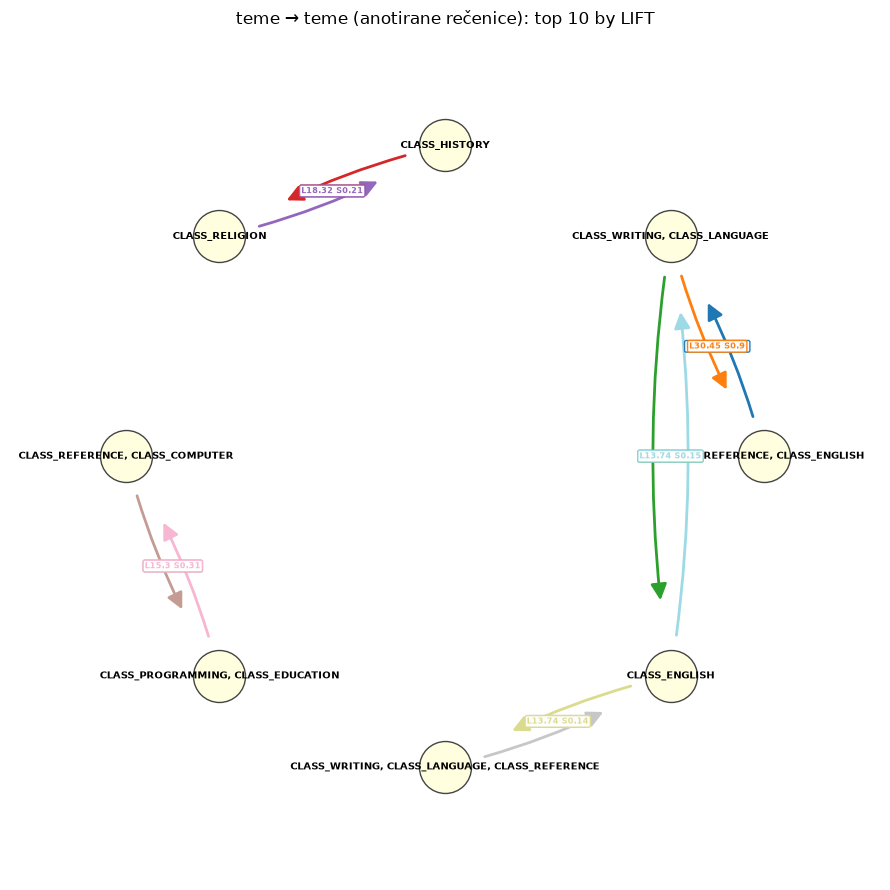

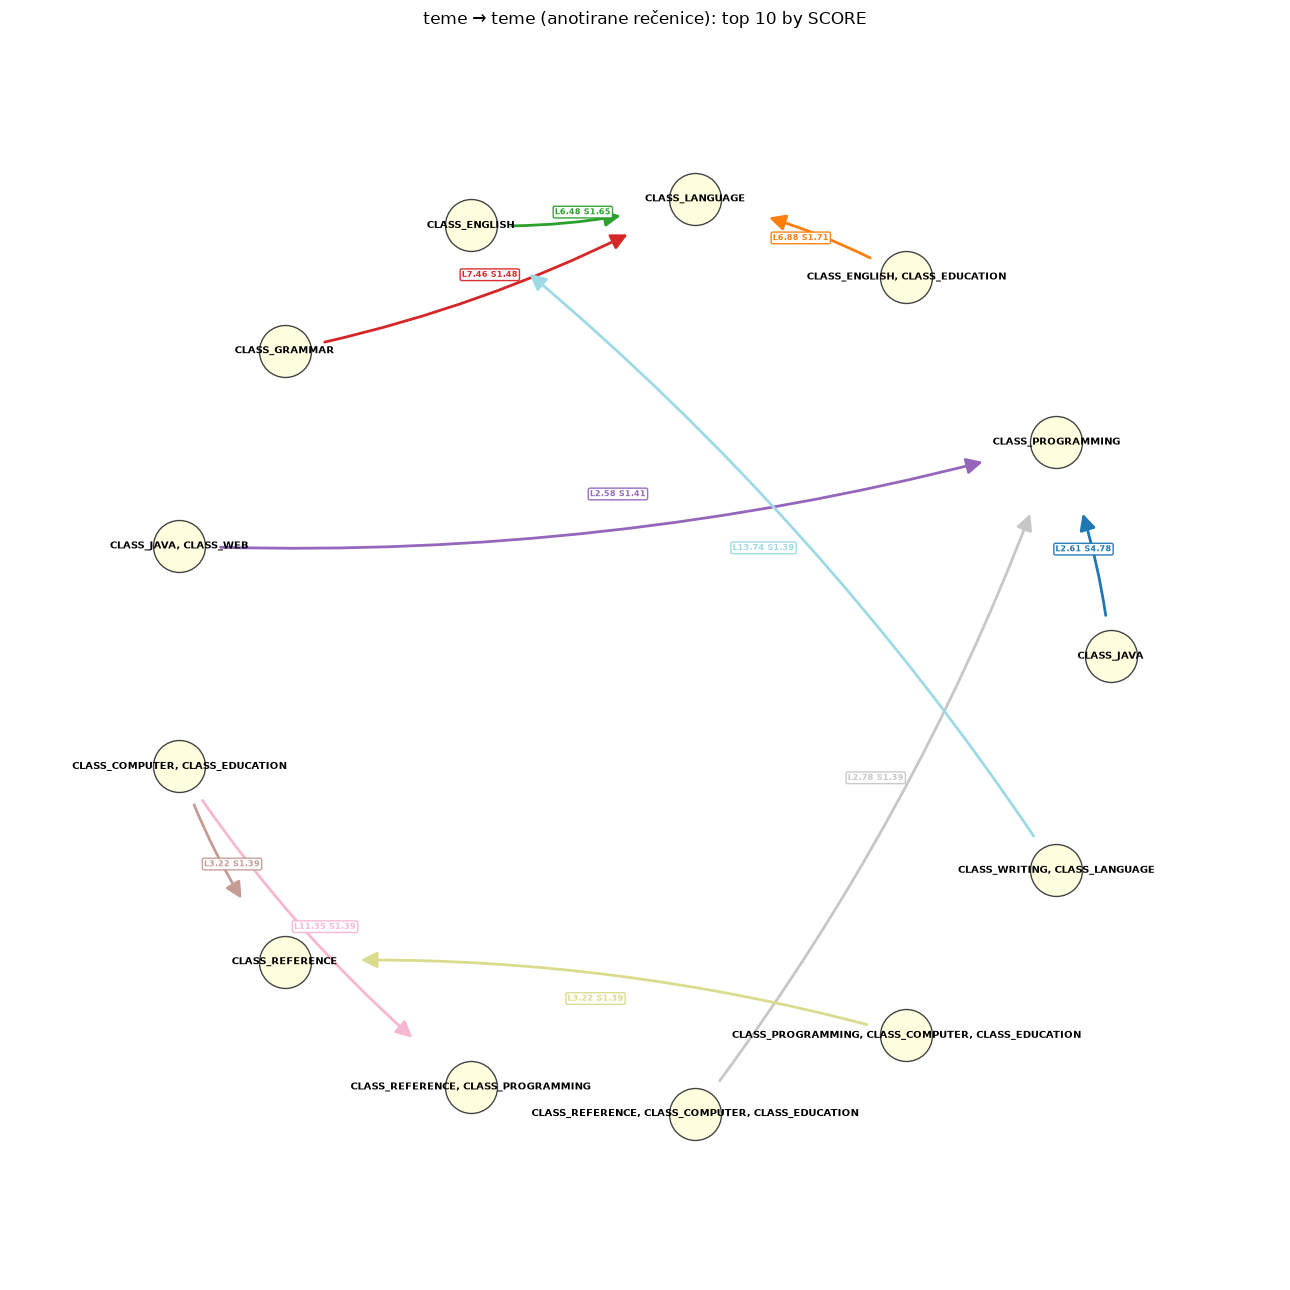

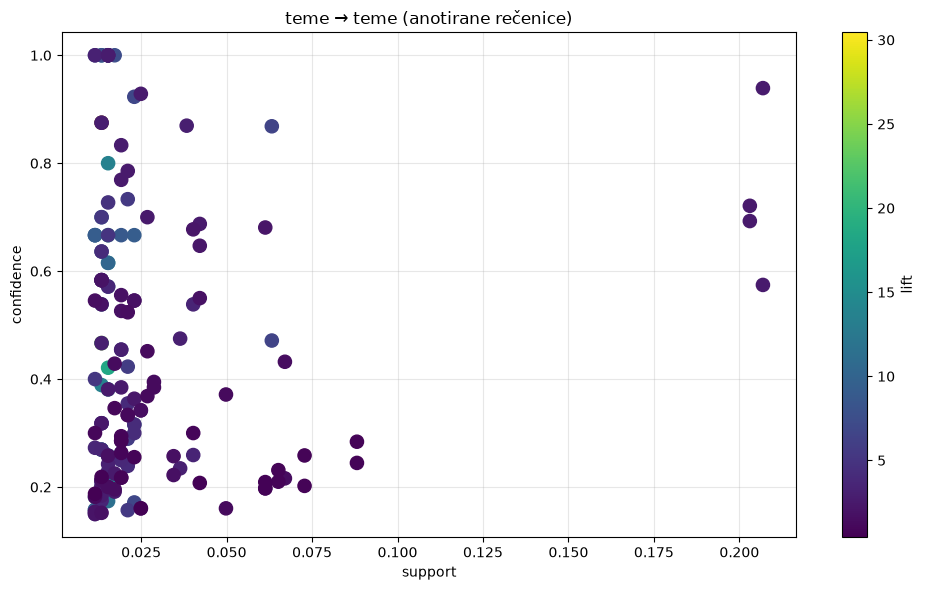

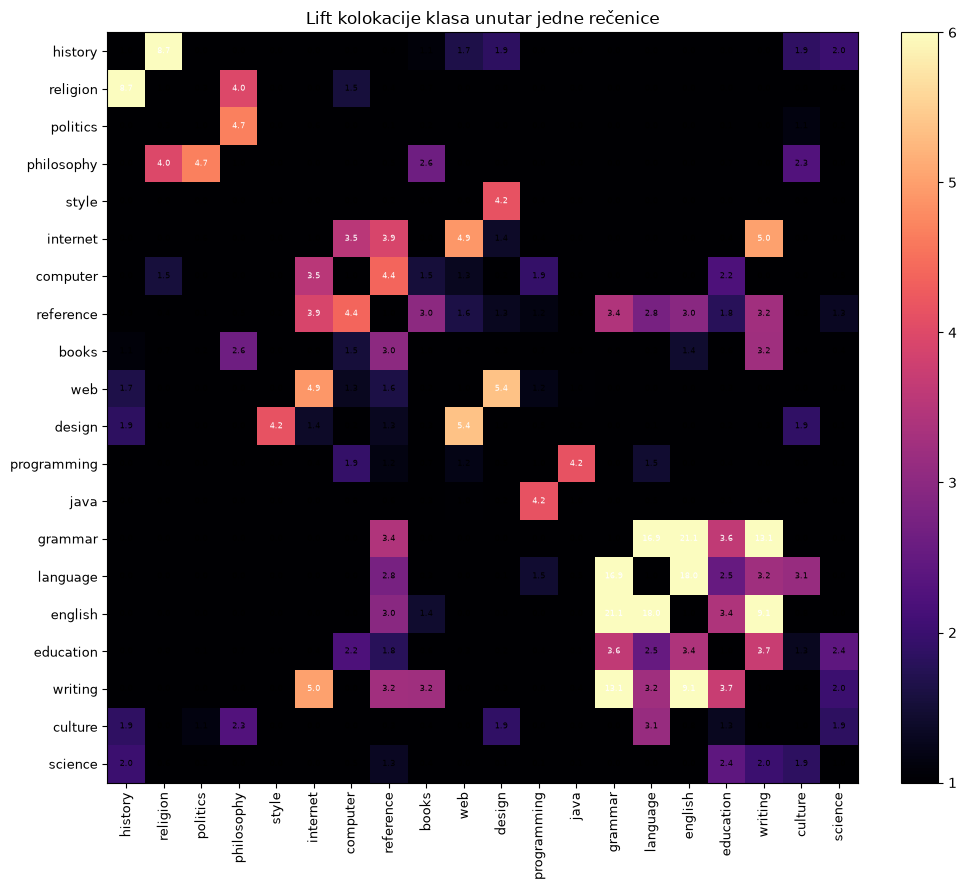


REČI → TEME (anotirane rečenice)
   antecedents         consequents  support  confidence      lift  leverage  conviction    score
 (sourc, open)        (CLASS_JAVA) 0.004087    1.000000 11.379845  0.003728         inf 0.144141
(student, use)   (CLASS_EDUCATION) 0.004768    1.000000  9.986395  0.004291         inf 0.155690
   (use, code) (CLASS_PROGRAMMING) 0.004087    1.000000  4.959459  0.003263         inf 0.144141
 (sourc, code) (CLASS_PROGRAMMING) 0.005450    1.000000  4.959459  0.004351         inf 0.166440
 (sourc, open) (CLASS_PROGRAMMING) 0.004087    1.000000  4.959459  0.003263         inf 0.144141
(more, inform)   (CLASS_REFERENCE) 0.005450    0.615385  4.632742  0.004273    2.254632 0.166440


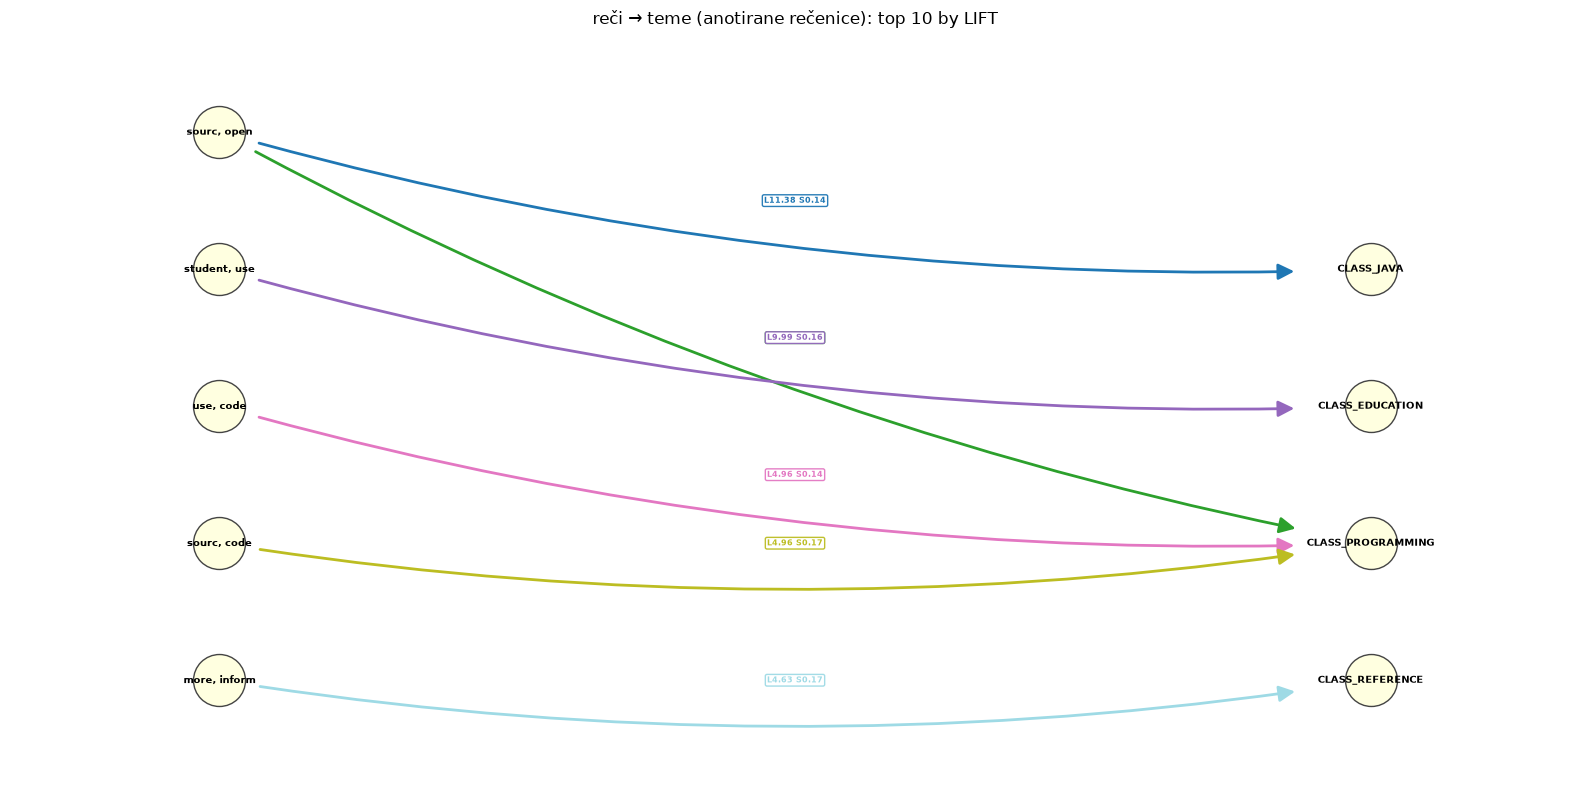

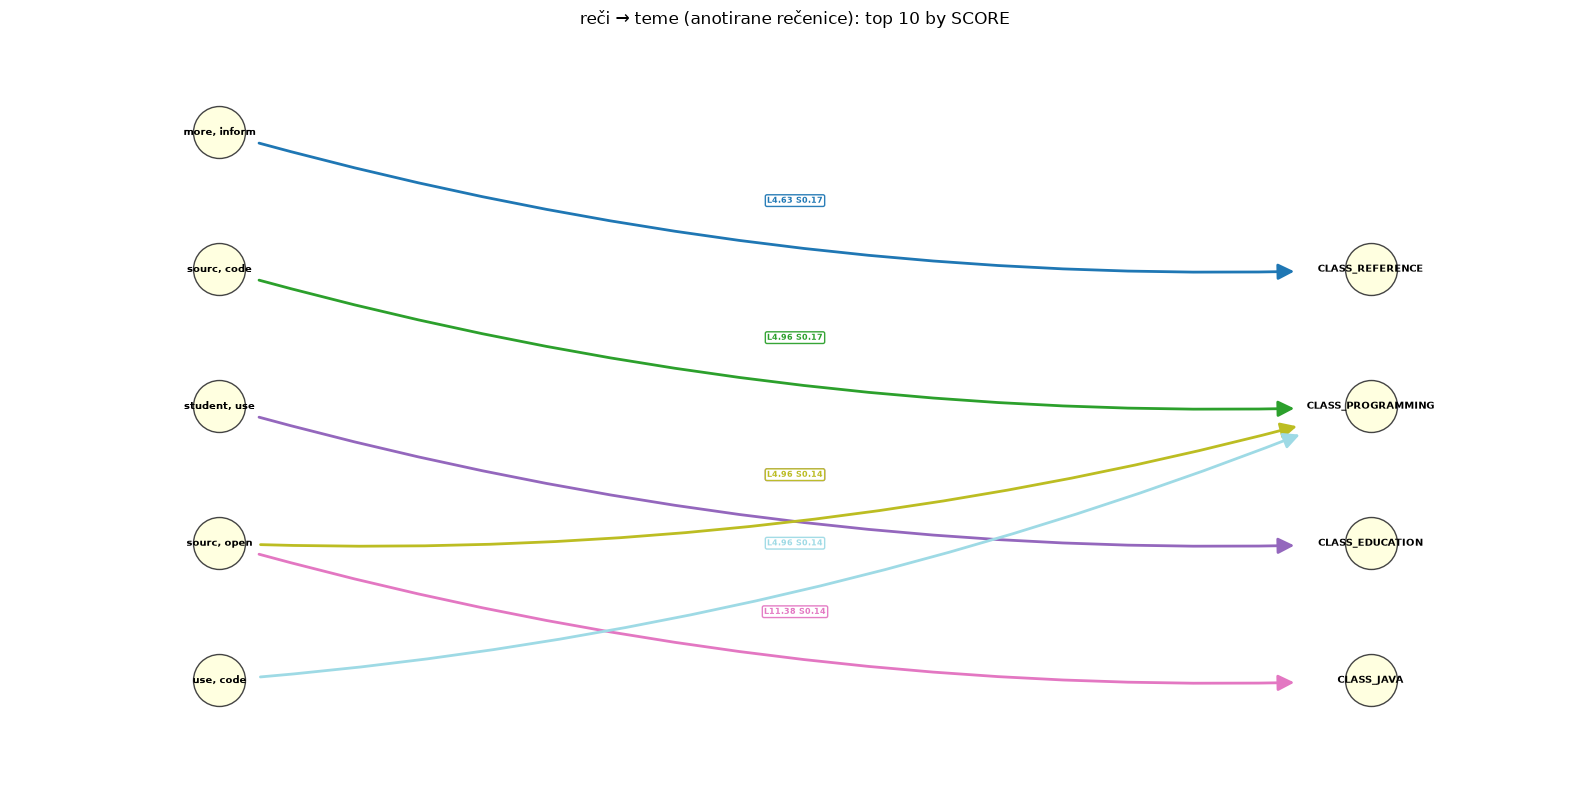

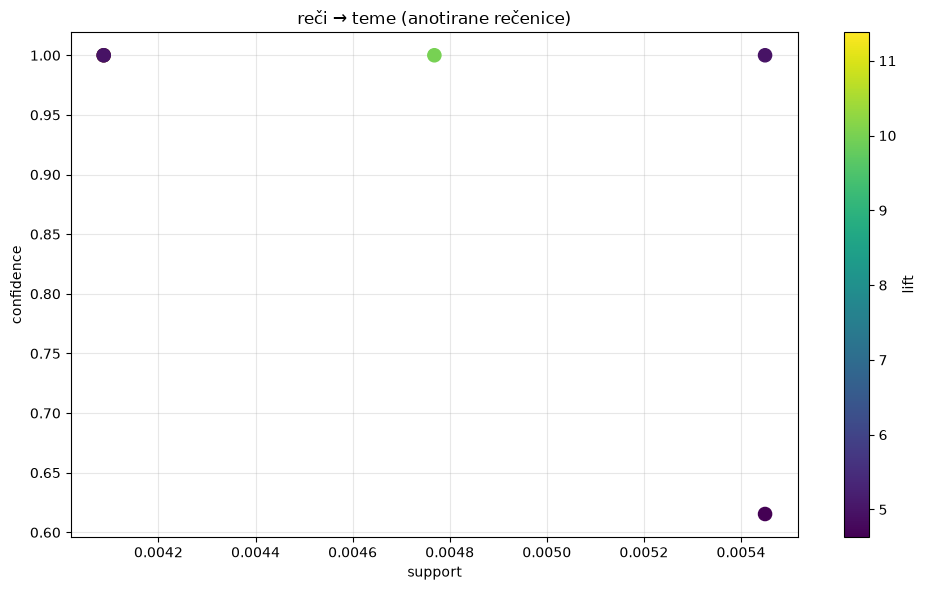


REČ → REČ (anotirane rečenice)
     antecedents      consequents  support  confidence      lift  leverage  conviction    score
(document, text)           (type) 0.013624    1.000000 41.942857  0.013299         inf 2.394387
          (type) (document, text) 0.013624    0.571429 41.942857  0.013299    2.301544 0.268640
(type, document)           (text) 0.013624    0.952381 41.120448  0.013293   20.513624 2.394387
          (text) (type, document) 0.013624    0.588235 41.120448  0.013293    2.393830 0.279412
    (type, text)       (document) 0.013624    1.000000 32.622222  0.013206         inf 2.394387
      (document)     (type, text) 0.013624    0.444444 32.622222  0.013206    1.775477 0.207237
          (type)           (text) 0.013624    0.571429 24.672269  0.013072    2.279292 0.266043
          (text)           (type) 0.013624    0.588235 24.672269  0.013072    2.370670 0.276709
          (type)       (document) 0.014305    0.600000 19.573333  0.013574    2.423365 0.289845
      (d

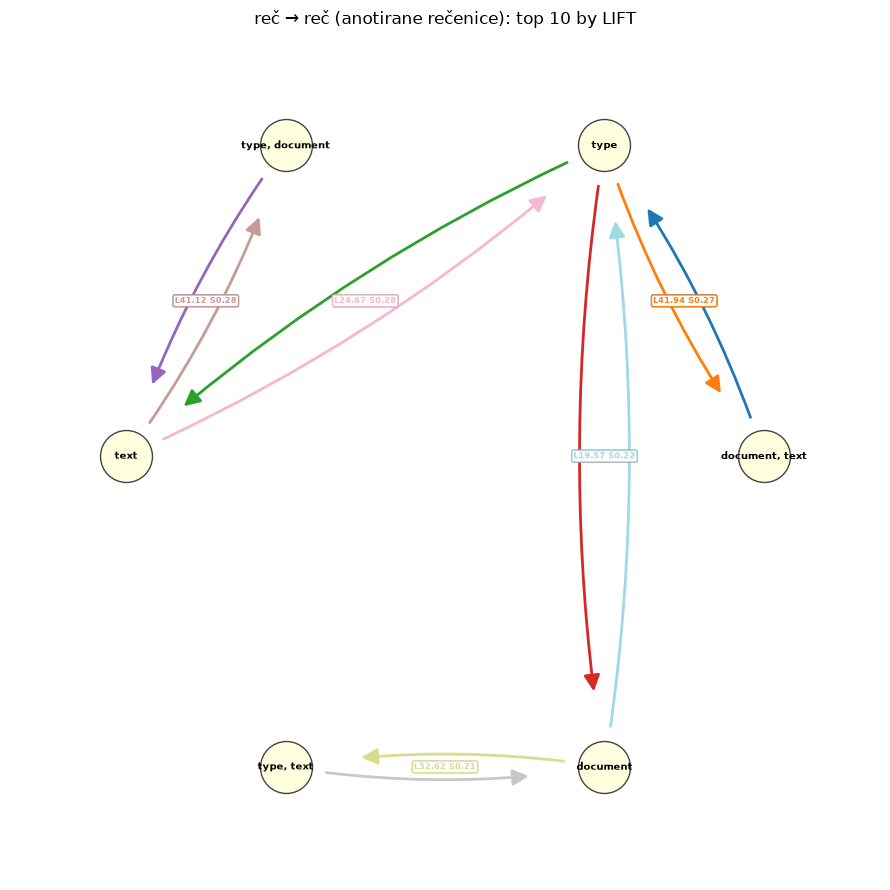

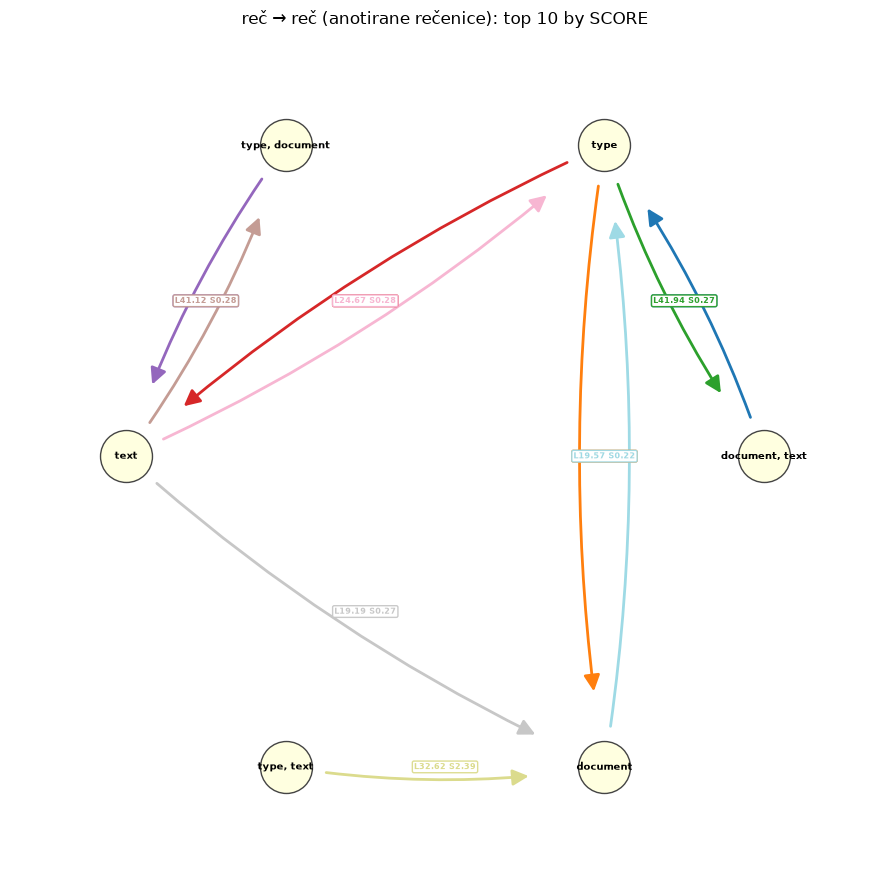

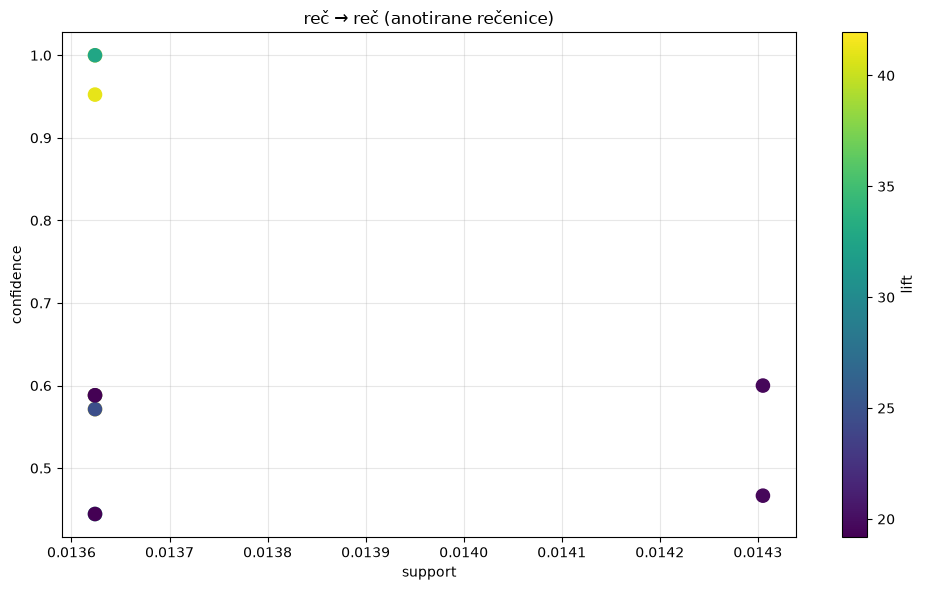

In [22]:
annotated_sentence_rules(vocab)